In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import xarray as xr
import openpyxl
import os
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf


# Output setup
OUTPUT_DIR = "Code Outputs/Lake Level Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
def out(n): return os.path.join(OUTPUT_DIR, n)

In [2]:
# Load DAHITI data
dahiti_text_victoria = """datetime;wse;wse_u
1992-09-27 19:36:13;1135.000;0.000
1992-10-07 17:34:42;1135.023;0.001
1992-10-17 15:33:12;1135.032;0.000
1992-10-27 13:31:44;1134.958;0.000
1992-11-06 11:30:16;1135.035;0.000
1992-11-16 09:28:48;1135.048;0.001
1992-11-26 07:27:20;1135.107;0.001
1992-12-06 05:25:51;1135.025;0.000
1992-12-16 03:24:22;1135.103;0.000
1992-12-26 01:22:54;1135.168;0.000
1993-01-04 23:21:25;1135.145;0.000
1993-01-14 21:19:57;1135.181;0.000
1993-01-24 19:18:29;1135.183;0.001
1993-02-03 17:17:00;1135.292;0.000
1993-02-13 15:15:32;1135.122;0.001
1993-02-23 13:14:03;1135.164;0.001
1993-03-05 11:12:34;1135.136;0.001
1993-03-15 09:11:06;1135.168;0.001
1993-03-25 07:09:37;1135.228;0.000
1993-04-14 03:06:40;1135.128;0.001
1993-04-24 01:05:12;1135.129;0.001
1993-05-03 23:03:44;1135.096;0.001
1993-05-13 21:02:16;1135.176;0.002
1993-05-23 19:00:48;1135.263;0.001
1993-06-02 16:59:19;1135.310;0.001
1993-06-12 14:57:50;1135.340;0.001
1993-06-22 12:56:21;1135.310;0.002
1993-07-02 10:54:52;1135.204;0.000
1993-07-12 08:53:23;1135.165;0.000
1993-07-22 06:51:54;1135.096;0.001
1993-08-01 04:50:24;1135.059;0.001
1993-08-11 02:48:55;1135.085;0.001
1993-08-21 00:47:27;1135.004;0.001
1993-08-30 22:45:59;1134.906;0.001
1993-09-09 20:44:31;1134.908;0.001
1993-09-19 18:43:02;1134.832;0.000
1993-09-29 16:41:34;1134.819;0.001
1993-10-09 14:40:05;1134.842;0.001
1993-10-19 12:38:37;1134.845;0.000
1993-11-08 08:35:40;1134.751;0.000
1993-11-18 06:34:12;1134.775;0.000
1993-11-28 04:32:43;1134.680;0.000
1993-12-08 02:31:14;1134.788;0.001
1993-12-18 00:29:46;1134.703;0.001
1993-12-27 22:28:17;1134.712;0.001
1994-01-06 20:26:48;1134.642;0.001
1994-01-16 18:25:18;1134.623;0.001
1994-01-26 16:23:49;1134.616;0.000
1994-02-05 14:22:20;1134.675;0.001
1994-02-15 12:20:52;1134.664;0.002
1994-02-25 10:19:24;1134.598;0.000
1994-03-07 08:17:56;1134.595;0.000
1994-03-27 04:15:00;1134.755;0.000
1994-04-06 02:13:31;1134.648;0.001
1994-04-16 00:12:02;1134.735;0.001
1994-04-25 22:10:33;1134.811;0.000
1994-05-05 20:09:04;1134.776;0.000
1994-05-15 18:07:35;1134.835;0.000
1994-05-25 16:06:07;1134.908;0.001
1994-06-04 14:04:39;1134.918;0.000
1994-06-14 12:03:11;1134.952;0.001
1994-06-24 10:01:43;1134.881;0.001
1994-07-04 08:00:14;1134.864;0.001
1994-07-14 05:58:45;1134.649;0.000
1994-07-24 03:57:17;1134.800;0.001
1994-08-03 01:55:48;1134.796;0.000
1994-08-12 23:54:19;1134.752;0.000
1994-08-22 21:52:50;1134.783;0.001
1994-09-01 19:51:21;1134.728;0.000
1994-09-11 17:49:52;1134.678;0.000
1994-09-21 15:48:23;1134.605;0.000
1994-10-01 13:46:54;1134.612;0.001
1994-10-11 11:45:25;1134.701;0.001
1994-10-21 09:43:58;1134.650;0.001
1994-10-31 07:42:30;1134.621;0.000
1994-11-10 05:41:02;1134.728;0.002
1994-11-20 03:39:34;1134.763;0.001
1994-11-30 01:38:05;1134.798;0.008
1994-12-09 23:36:37;1135.160;0.004
1994-12-19 21:35:09;1135.002;0.000
1994-12-29 19:33:41;1134.941;0.000
1995-01-08 17:32:12;1134.890;0.001
1995-01-18 15:30:43;1134.931;0.001
1995-01-28 13:29:15;1134.879;0.001
1995-02-07 11:27:46;1134.879;0.000
1995-02-17 09:26:18;1134.954;0.001
1995-02-27 07:24:50;1134.893;0.003
1995-03-09 05:23:21;1134.907;0.002
1995-03-19 03:21:53;1134.882;0.001
1995-03-29 01:20:24;1134.868;0.000
1995-04-07 23:18:55;1134.918;0.001
1995-04-17 21:17:26;1135.021;0.000
1995-04-27 19:15:57;1135.053;0.000
1995-05-07 17:14:28;1135.049;0.002
1995-05-17 15:12:59;1135.111;0.000
1995-05-27 13:11:31;1135.075;0.000
1995-06-06 11:10:03;1135.187;0.000
1995-06-16 09:08:35;1135.154;0.000
1995-06-26 07:07:07;1135.159;0.001
1995-07-06 05:05:39;1135.127;0.002
1995-07-16 03:04:11;1135.078;0.001
1995-07-26 01:02:42;1135.062;0.000
1995-08-04 23:01:14;1135.054;0.000
1995-08-14 20:59:45;1134.945;0.000
1995-08-24 18:58:16;1134.962;0.000
1995-09-03 16:56:48;1134.870;0.000
1995-09-13 14:55:19;1134.938;0.001
1995-09-23 12:53:50;1134.828;0.000
1995-10-03 10:52:22;1134.894;0.002
1995-10-13 08:50:53;1134.878;0.001
1995-10-23 06:49:25;1134.862;0.004
1995-11-02 04:47:57;1134.862;0.001
1995-11-12 02:46:28;1134.854;0.000
1995-11-22 00:45:00;1134.848;0.000
1995-12-11 20:42:02;1134.918;0.000
1995-12-21 18:40:33;1134.921;0.001
1995-12-31 16:39:04;1134.917;0.001
1996-01-10 14:37:34;1135.004;0.001
1996-01-30 10:34:39;1134.920;0.000
1996-02-09 08:33:11;1134.976;0.001
1996-02-29 04:30:15;1135.070;0.001
1996-03-10 02:28:47;1135.048;0.001
1996-03-20 00:27:18;1134.953;0.002
1996-03-29 22:25:50;1135.061;0.001
1996-04-08 20:24:21;1135.168;0.000
1996-04-18 18:22:53;1135.307;0.000
1996-04-28 16:21:24;1135.264;0.001
1996-05-08 14:19:56;1135.296;0.000
1996-05-18 12:18:27;1135.281;0.002
1996-05-28 10:16:59;1135.344;0.001
1996-06-07 08:15:31;1135.290;0.000
1996-06-17 06:14:02;1135.214;0.002
1996-06-27 04:12:34;1135.297;0.002
1996-07-07 02:11:05;1135.204;0.000
1996-07-17 00:09:36;1135.205;0.000
1996-07-26 22:08:07;1135.150;0.001
1996-08-05 20:06:38;1135.180;0.002
1996-08-15 18:05:09;1135.132;0.001
1996-08-25 16:03:41;1135.089;0.001
1996-09-04 14:02:12;1135.144;0.001
1996-09-14 12:00:43;1135.068;0.000
1996-09-24 09:59:15;1135.137;0.000
1996-10-04 07:57:47;1135.053;0.001
1996-10-14 05:56:19;1135.108;0.001
1996-10-24 03:54:50;1135.068;0.001
1996-11-03 01:53:22;1135.025;0.000
1996-11-12 23:51:53;1134.984;0.000
1996-11-22 21:50:24;1134.991;0.001
1996-12-02 19:48:56;1135.010;0.000
1996-12-12 17:47:27;1135.059;0.001
1996-12-22 15:45:59;1135.094;0.000
1997-01-01 13:44:30;1135.092;0.000
1997-01-11 11:43:02;1135.054;0.000
1997-01-21 09:41:34;1135.065;0.001
1997-01-31 07:40:06;1135.030;0.001
1997-02-10 05:38:38;1134.911;0.002
1997-02-20 03:37:09;1134.939;0.000
1997-03-02 01:35:41;1134.922;0.000
1997-03-11 23:34:12;1134.863;0.000
1997-03-21 21:32:44;1134.809;0.000
1997-03-31 19:31:16;1134.792;0.000
1997-04-10 17:29:48;1134.878;0.000
1997-04-20 15:28:19;1134.970;0.000
1997-04-30 13:26:51;1135.062;0.001
1997-05-10 11:25:23;1135.171;0.000
1997-05-20 09:23:55;1135.206;0.001
1997-05-30 07:22:26;1135.069;0.000
1997-06-09 05:20:58;1135.049;0.002
1997-06-19 03:19:30;1135.027;0.001
1997-06-29 01:18:01;1135.040;0.001
1997-07-08 23:16:31;1135.034;0.000
1997-07-18 21:15:03;1134.891;0.000
1997-07-28 19:13:34;1134.932;0.000
1997-08-17 15:10:37;1134.874;0.001
1997-08-27 13:09:08;1134.837;0.001
1997-09-06 11:07:40;1134.767;0.001
1997-09-16 09:06:12;1134.731;0.001
1997-09-26 07:04:44;1134.704;0.001
1997-10-06 05:03:15;1134.578;0.002
1997-10-16 03:01:47;1134.552;0.001
1997-10-26 01:00:18;1134.693;0.001
1997-11-04 22:58:49;1134.756;0.002
1997-11-14 20:57:20;1134.807;0.000
1997-11-24 18:55:51;1135.016;0.006
1997-12-04 16:54:23;1135.116;0.000
1997-12-14 14:52:54;1135.256;0.000
1997-12-24 12:51:25;1135.428;0.001
1998-01-03 10:49:57;1135.506;0.001
1998-01-13 08:48:29;1135.679;0.001
1998-02-02 04:45:33;1135.739;0.001
1998-02-12 02:44:05;1135.761;0.001
1998-02-22 00:42:36;1135.778;0.000
1998-03-03 22:41:08;1135.809;0.001
1998-03-13 20:39:40;1135.790;0.001
1998-03-23 18:38:12;1135.843;0.001
1998-04-02 16:36:43;1135.870;0.001
1998-04-12 14:35:14;1135.889;0.000
1998-04-22 12:33:46;1136.024;0.001
1998-05-02 10:32:17;1136.099;0.000
1998-05-12 08:30:49;1136.187;0.001
1998-05-22 06:29:21;1136.217;0.001
1998-06-01 04:27:53;1136.165;0.000
1998-06-11 02:26:24;1136.150;0.001
1998-06-21 00:24:55;1136.106;0.001
1998-06-30 22:23:26;1136.122;0.000
1998-07-10 20:21:57;1135.990;0.001
1998-07-20 18:20:29;1135.980;0.001
1998-08-09 14:17:32;1135.876;0.001
1998-08-19 12:16:03;1135.849;0.001
1998-08-29 10:14:35;1135.831;0.001
1998-09-08 08:13:07;1135.869;0.001
1998-09-18 06:11:39;1135.765;0.001
1998-09-28 04:10:12;1135.527;0.021
1998-10-08 02:08:42;1135.742;0.000
1998-10-18 00:07:13;1135.676;0.001
1998-10-27 22:05:44;1135.717;0.000
1998-11-06 20:04:15;1135.728;0.001
1998-11-16 18:02:46;1135.754;0.001
1998-11-26 16:01:17;1135.714;0.001
1998-12-06 13:59:48;1135.680;0.001
1998-12-16 11:58:20;1135.717;0.000
1998-12-26 09:56:52;1135.687;0.001
1999-01-05 07:55:23;1135.668;0.000
1999-01-15 05:53:56;1135.902;0.006
1999-02-04 01:50:58;1135.562;0.001
1999-02-13 23:49:29;1135.578;0.001
1999-02-23 21:48:01;1135.508;0.000
1999-03-05 19:46:33;1135.476;0.001
1999-03-15 17:45:04;1135.578;0.001
1999-03-25 15:43:35;1135.667;0.000
1999-04-04 13:42:07;1135.712;0.000
1999-04-14 11:40:38;1135.678;0.000
1999-04-24 09:39:10;1135.727;0.000
1999-05-04 07:37:41;1135.836;0.001
1999-05-14 05:36:13;1135.812;0.000
1999-05-24 03:34:44;1135.846;0.000
1999-06-03 01:33:15;1135.714;0.001
1999-06-12 23:31:46;1135.701;0.000
1999-06-22 21:30:18;1135.665;0.000
1999-07-02 19:28:51;1135.641;0.000
1999-07-12 17:27:22;1135.479;0.001
1999-07-22 15:25:54;1135.438;0.001
1999-08-01 13:24:25;1135.447;0.001
1999-08-11 11:22:57;1135.395;0.001
1999-08-21 09:21:28;1135.388;0.000
1999-09-10 05:18:32;1135.436;0.001
1999-09-20 03:17:03;1135.381;0.002
1999-09-30 01:15:33;1135.305;0.001
1999-10-09 23:14:04;1135.339;0.001
1999-10-19 21:12:35;1135.350;0.001
1999-10-29 19:11:07;1135.343;0.001
1999-11-08 17:09:38;1135.372;0.001
1999-11-18 15:08:10;1135.328;0.000
1999-12-08 11:05:12;1135.404;0.000
1999-12-18 09:03:44;1135.525;0.001
1999-12-28 07:02:15;1135.448;0.000
2000-01-07 05:00:47;1135.476;0.001
2000-01-17 02:59:19;1135.474;0.001
2000-01-27 00:57:51;1135.507;0.000
2000-02-05 22:56:23;1135.380;0.001
2000-02-15 20:54:55;1135.345;0.000
2000-02-25 18:53:26;1135.336;0.002
2000-03-06 16:51:57;1135.354;0.001
2000-03-16 14:50:28;1135.366;0.000
2000-03-26 12:48:59;1135.351;0.001
2000-04-05 10:47:30;1135.189;0.001
2000-04-15 08:46:00;1135.346;0.001
2000-04-25 06:44:32;1135.341;0.001
2000-05-05 04:43:04;1135.331;0.002
2000-05-15 02:41:36;1135.324;0.001
2000-06-03 22:38:38;1135.266;0.001
2000-06-13 20:37:09;1135.142;0.002
2000-06-23 18:35:40;1135.047;0.000
2000-07-03 16:34:12;1135.131;0.001
2000-07-13 14:32:43;1135.014;0.001
2000-07-23 12:31:16;1134.950;0.000
2000-08-02 10:29:47;1135.027;0.001
2000-08-12 08:28:19;1134.889;0.002
2000-08-22 06:26:51;1134.890;0.002
2000-09-01 04:25:22;1134.785;0.000
2000-09-11 02:23:54;1134.815;0.000
2000-09-21 00:22:24;1134.764;0.000
2000-09-30 22:20:55;1134.804;0.001
2000-10-10 20:19:27;1134.752;0.000
2000-10-20 18:17:59;1134.780;0.001
2000-11-09 14:15:01;1134.793;0.001
2000-11-19 12:13:33;1134.801;0.001
2000-11-29 10:12:04;1134.987;0.000
2000-12-09 08:10:35;1134.911;0.000
2000-12-19 06:09:07;1135.001;0.001
2000-12-29 04:07:38;1134.977;0.000
2001-01-08 02:06:09;1135.049;0.000
2001-01-18 00:04:40;1135.015;0.000
2001-01-27 22:03:12;1135.130;0.001
2001-02-06 20:01:44;1135.080;0.002
2001-02-16 18:00:16;1135.108;0.000
2001-02-26 15:58:47;1135.122;0.001
2001-03-08 13:57:18;1135.034;0.001
2001-03-18 11:55:50;1135.028;0.001
2001-03-28 09:54:22;1134.986;0.000
2001-04-07 07:52:53;1135.108;0.000
2001-04-17 05:51:24;1135.100;0.002
2001-04-27 03:49:54;1135.131;0.001
2001-05-07 01:48:25;1135.161;0.001
2001-05-16 23:46:57;1135.118;0.001
2001-05-26 21:45:29;1135.196;0.000
2001-06-05 19:44:01;1135.245;0.001
2001-06-15 17:42:32;1135.171;0.001
2001-06-25 15:41:04;1135.142;0.001
2001-07-05 13:39:35;1135.111;0.002
2001-07-15 11:38:07;1135.017;0.000
2001-07-25 09:36:38;1135.103;0.000
2001-08-04 07:35:10;1135.103;0.000
2001-08-14 05:33:41;1134.991;0.001
2001-08-24 03:32:12;1135.007;0.000
2001-09-03 01:30:43;1134.907;0.000
2001-09-12 23:29:13;1134.885;0.001
2001-09-22 21:27:45;1134.955;0.001
2001-10-02 19:26:17;1134.924;0.000
2001-10-12 17:24:48;1134.976;0.000
2001-10-22 15:23:20;1134.945;0.001
2001-11-01 13:21:51;1134.955;0.001
2001-11-11 11:20:22;1135.020;0.001
2001-11-21 09:18:53;1135.129;0.000
2001-12-01 07:17:25;1135.139;0.000
2001-12-11 05:15:57;1135.095;0.000
2001-12-21 03:14:29;1135.051;0.000
2001-12-31 01:13:00;1135.005;0.000
2002-01-09 23:11:31;1135.085;0.001
2002-01-19 00:00:00;1135.140;0.000
2002-01-29 00:00:00;1135.079;0.000
2002-02-08 00:00:00;1135.104;0.000
2002-02-18 00:00:00;1135.108;0.000
2002-02-28 00:00:00;1135.006;0.000
2002-03-10 00:00:00;1135.001;0.000
2002-03-20 00:00:00;1135.107;0.000
2002-03-30 00:00:00;1135.224;0.000
2002-04-09 00:00:00;1135.233;0.000
2002-04-19 00:00:00;1135.227;0.000
2002-04-29 00:00:00;1135.265;0.000
2002-05-08 00:00:00;1135.452;0.000
2002-05-18 20:51:07;1135.445;0.000
2002-05-28 00:00:00;1135.428;0.001
2002-06-07 00:00:00;1135.490;0.000
2002-06-17 00:00:00;1135.385;0.000
2002-06-27 00:00:00;1135.315;0.000
2002-07-07 00:00:00;1135.244;0.000
2002-07-17 00:00:00;1135.243;0.000
2002-07-27 00:00:00;1135.259;0.000
2002-08-06 00:00:00;1135.142;0.000
2002-08-16 02:37:53;1135.101;0.001
2002-08-26 00:36:24;1135.042;0.000
2002-09-04 22:34:56;1135.068;0.000
2002-09-14 20:33:26;1135.053;0.001
2002-09-24 18:31:58;1134.946;0.000
2002-10-04 16:30:30;1134.871;0.000
2002-10-14 14:29:01;1134.999;0.014
2002-10-24 12:27:32;1134.959;0.000
2002-11-03 10:26:04;1134.886;0.001
2002-11-13 08:24:36;1134.947;0.001
2002-12-23 00:18:42;1135.115;0.001
2003-01-01 22:17:15;1135.135;0.000
2003-01-11 20:15:47;1135.187;0.000
2003-01-21 18:14:18;1135.143;0.000
2003-01-31 16:12:49;1135.108;0.000
2003-02-10 14:11:19;1135.124;0.000
2003-02-20 12:09:51;1135.120;0.001
2003-03-02 10:08:23;1134.972;0.001
2003-03-12 08:06:55;1135.014;0.001
2003-04-30 21:59:35;1135.104;0.000
2003-05-10 19:58:07;1135.131;0.001
2003-05-20 17:56:39;1135.204;0.000
2003-05-30 15:55:10;1135.193;0.000
2003-06-09 13:53:41;1135.276;0.001
2003-06-19 11:52:11;1135.230;0.001
2003-07-09 07:49:15;1135.193;0.000
2003-07-19 05:47:47;1135.150;0.000
2003-07-29 03:46:19;1135.177;0.000
2003-08-17 23:43:23;1135.007;0.000
2003-08-27 21:41:55;1135.132;0.000
2003-09-06 19:40:26;1135.076;0.000
2003-09-26 15:37:31;1134.954;0.064
2003-10-16 11:34:32;1135.006;0.000
2003-10-26 09:33:04;1134.919;0.000
2003-11-15 05:30:06;1134.907;0.001
2003-12-14 23:25:41;1134.964;0.000
2003-12-24 21:24:14;1135.043;0.000
2004-01-03 19:22:47;1134.948;0.000
2004-01-23 15:19:49;1134.855;0.000
2004-02-22 09:15:21;1134.896;0.000
2004-03-03 07:13:54;1134.808;0.000
2004-03-13 05:12:27;1134.859;0.000
2004-03-23 03:10:59;1134.772;0.000
2004-04-02 01:09:31;1134.758;0.000
2004-04-11 23:08:04;1134.835;0.000
2004-04-21 21:06:36;1134.953;0.000
2004-05-01 19:05:08;1134.987;0.000
2004-05-11 17:03:39;1135.064;0.001
2004-05-21 15:02:10;1135.021;0.000
2004-07-10 04:54:48;1134.729;0.001
2004-07-20 02:53:21;1134.666;0.000
2004-07-30 00:51:53;1134.632;0.000
2004-08-08 22:50:25;1134.584;0.000
2004-08-18 20:48:57;1134.601;0.000
2004-09-07 16:45:59;1134.499;0.000
2004-10-07 10:41:32;1134.443;0.000
2004-10-17 08:40:03;1134.415;0.001
2004-11-16 02:35:40;1134.393;0.001
2004-11-26 00:34:12;1134.407;0.001
2004-12-05 22:32:44;1134.452;0.000
2004-12-25 18:29:47;1134.504;0.000
2005-01-04 16:28:18;1134.444;0.001
2005-01-14 14:26:48;1134.462;0.000
2005-01-24 12:25:20;1134.366;0.000
2005-02-03 10:23:52;1134.492;0.000
2005-02-23 06:20:57;1134.399;0.000
2005-03-05 04:19:29;1134.382;0.001
2005-03-15 02:18:01;1134.344;0.000
2005-03-25 00:16:34;1134.360;0.000
2005-04-03 22:15:05;1134.334;0.000
2005-04-13 20:13:38;1134.367;0.000
2005-04-23 18:12:09;1134.439;0.001
2005-05-13 14:09:11;1134.494;0.000
2005-07-02 04:01:52;1134.481;0.000
2005-07-31 21:57:29;1134.300;0.001
2005-08-10 19:56:01;1134.261;0.000
2005-08-20 17:54:32;1134.269;0.000
2005-08-30 15:53:04;1134.213;0.000
2005-09-09 13:51:35;1134.251;0.000
2005-09-19 11:50:06;1134.185;0.000
2005-09-29 09:48:37;1134.109;0.000
2005-10-09 07:47:09;1134.125;0.000
2005-10-19 05:45:42;1134.119;0.001
2005-10-29 03:44:14;1134.166;0.000
2005-11-08 01:42:47;1134.200;0.001
2005-11-27 21:39:51;1134.168;0.001
2005-12-07 19:38:22;1134.070;0.000
2005-12-17 17:36:53;1134.036;0.000
2005-12-27 15:35:24;1134.022;0.000
2006-01-06 13:33:55;1133.954;0.000
2006-01-16 11:32:27;1133.968;0.000
2006-01-26 09:30:59;1133.998;0.000
2006-02-05 07:29:31;1133.931;0.001
2006-02-15 05:28:05;1133.862;0.001
2006-02-25 03:26:37;1133.875;0.000
2006-03-07 01:25:09;1133.887;0.000
2006-03-16 23:23:40;1133.848;0.000
2006-03-26 21:22:12;1133.981;0.001
2006-04-05 19:20:44;1133.971;0.000
2006-04-15 17:19:15;1134.007;0.000
2006-04-25 15:17:46;1134.136;0.001
2006-05-15 11:14:50;1134.259;0.000
2006-06-14 05:10:24;1133.869;0.000
2006-06-24 03:08:55;1134.188;0.000
2006-07-04 01:07:27;1134.141;0.001
2006-07-23 21:04:31;1134.019;0.000
2006-08-02 19:03:03;1133.979;0.000
2006-08-12 17:01:35;1133.993;0.000
2006-09-01 12:58:39;1133.978;0.000
2006-09-11 10:57:10;1133.955;0.001
2006-09-21 08:55:41;1133.813;0.000
2006-10-01 06:54:13;1133.823;0.000
2006-10-11 04:52:45;1133.748;0.000
2006-10-21 02:51:18;1133.743;0.001
2006-11-19 20:46:54;1133.926;0.000
2006-11-29 18:45:25;1134.042;0.001
2006-12-09 16:43:57;1134.164;0.000
2006-12-19 14:42:28;1134.262;0.001
2006-12-29 12:41:00;1134.309;0.000
2007-01-08 10:39:32;1134.370;0.000
2007-01-18 08:38:03;1134.446;0.001
2007-01-28 06:36:35;1134.371;0.000
2007-02-07 04:35:08;1134.510;0.001
2007-02-17 02:33:40;1134.470;0.000
2007-02-27 00:32:13;1134.489;0.001
2007-03-18 20:29:17;1134.527;0.001
2007-03-28 18:27:48;1134.498;0.000
2007-04-07 16:26:20;1134.459;0.000
2007-04-17 14:24:51;1134.496;0.000
2007-04-27 12:23:21;1134.606;0.001
2007-05-07 10:21:53;1134.648;0.000
2007-05-17 08:20:25;1134.616;0.000
2007-05-27 06:18:57;1134.631;0.001
2007-06-06 04:17:29;1134.584;0.000
2007-06-16 02:16:01;1134.643;0.001
2007-06-26 00:14:32;1134.647;0.000
2007-07-15 20:11:36;1134.610;0.001
2007-07-25 18:10:08;1134.563;0.000
2007-08-04 16:08:39;1134.519;0.000
2007-08-14 14:07:10;1134.545;0.001
2007-09-03 10:04:14;1134.552;0.000
2007-09-13 08:02:47;1134.552;0.001
2007-09-23 06:01:18;1134.581;0.000
2007-10-03 03:59:50;1134.569;0.000
2007-10-13 01:58:22;1134.520;0.001
2007-10-22 23:56:54;1134.464;0.011
2007-11-01 21:55:26;1134.486;0.001
2007-11-11 19:53:57;1134.584;0.000
2007-11-21 17:52:28;1134.542;0.001
2007-12-01 15:51:00;1134.523;0.001
2007-12-11 13:49:32;1134.530;0.000
2007-12-21 11:48:03;1134.526;0.001
2007-12-31 09:46:35;1134.589;0.001
2008-01-10 07:45:08;1134.491;0.000
2008-01-20 05:43:40;1134.520;0.000
2008-01-30 03:42:12;1134.587;0.001
2008-02-09 01:40:44;1134.509;0.000
2008-02-18 23:39:16;1134.566;0.001
2008-02-28 21:37:48;1134.562;0.001
2008-03-09 19:36:20;1134.561;0.001
2008-04-08 13:31:54;1134.588;0.000
2008-04-18 11:30:24;1134.677;0.000
2008-04-28 09:28:56;1134.734;0.000
2008-05-18 05:25:59;1134.703;0.000
2008-05-28 03:24:31;1134.704;0.001
2008-06-07 01:23:03;1134.727;0.004
2008-06-16 23:21:35;1134.740;0.000
2008-06-26 21:20:07;1134.537;0.000
2008-07-06 19:18:38;1134.586;0.001
2008-07-16 17:17:33;1134.593;0.001
2008-07-26 15:16:04;1134.571;0.001
2008-08-05 13:15:08;1134.589;0.000
2008-08-25 09:11:38;1134.494;0.000
2008-09-04 07:09:48;1134.470;0.001
2008-09-14 05:08:51;1134.558;0.002
2008-09-24 03:07:13;1134.467;0.000
2008-10-04 01:05:45;1134.530;0.000
2008-10-13 23:04:18;1134.453;0.000
2008-10-23 21:03:22;1134.533;0.001
2008-11-02 19:00:57;1134.578;0.001
2008-11-12 16:59:29;1134.624;0.000
2008-11-22 14:58:01;1134.664;0.000
2008-12-02 12:56:56;1134.593;0.000
2008-12-12 10:55:23;1134.633;0.000
2008-12-22 08:53:35;1134.636;0.000
2009-01-01 06:52:27;1134.601;0.000
2009-01-11 04:51:01;1134.576;0.000
2009-01-21 02:50:06;1134.524;0.000
2009-01-31 00:48:38;1134.571;0.001
2009-02-19 20:45:42;1134.568;0.001
2009-03-01 18:44:14;1134.555;0.000
2009-03-11 16:42:45;1134.607;0.000
2009-03-21 14:41:16;1134.613;0.002
2009-03-31 12:39:47;1134.651;0.001
2009-04-10 10:38:18;1134.683;0.001
2009-04-20 08:36:49;1134.749;0.001
2009-04-30 06:35:20;1134.789;0.001
2009-05-10 04:33:52;1134.789;0.001
2009-05-20 02:32:24;1134.973;0.001
2009-05-30 00:30:56;1134.877;0.001
2009-06-18 20:27:59;1134.797;0.000
2009-06-28 18:26:31;1134.697;0.001
2009-07-08 16:25:03;1134.680;0.000
2009-07-18 14:23:34;1134.673;0.001
2009-07-28 12:22:05;1134.649;0.001
2009-08-17 08:19:08;1134.589;0.000
2009-08-27 06:17:39;1134.495;0.000
2009-09-06 04:16:12;1134.389;0.001
2009-09-26 00:13:15;1134.503;0.000
2009-10-05 22:11:47;1134.449;0.000
2009-10-15 20:10:19;1134.449;0.001
2009-10-25 18:08:50;1134.432;0.001
2009-11-04 16:07:21;1134.418;0.001
2009-11-14 14:05:53;1134.434;0.002
2009-11-24 12:04:24;1134.502;0.000
2009-12-04 10:02:55;1134.517;0.001
2009-12-14 08:01:26;1134.519;0.000
2009-12-24 05:59:58;1134.441;0.001
2010-01-03 03:58:30;1134.618;0.001
2010-01-13 01:57:02;1134.604;0.001
2010-02-01 21:54:06;1134.595;0.001
2010-02-11 19:52:38;1134.594;0.000
2010-02-21 17:51:09;1134.575;0.000
2010-03-03 15:49:41;1134.676;0.000
2010-03-13 13:48:12;1134.689;0.002
2010-03-23 11:46:43;1134.729;0.000
2010-04-02 09:45:14;1134.872;0.000
2010-04-22 05:42:17;1134.857;0.000
2010-05-02 03:40:49;1134.902;0.001
2010-05-21 23:37:52;1135.048;0.001
2010-05-31 21:36:23;1135.030;0.001
2010-06-20 17:33:26;1135.008;0.000
2010-06-30 15:31:57;1134.885;0.001
2010-07-10 13:30:28;1134.851;0.000
2010-07-20 11:28:59;1134.817;0.001
2010-07-30 09:27:31;1134.822;0.000
2010-08-09 07:26:03;1134.821;0.001
2010-08-19 05:24:35;1134.765;0.000
2010-09-08 01:21:39;1134.710;0.001
2010-09-17 23:20:10;1134.732;0.000
2010-09-27 21:18:42;1134.660;0.001
2010-10-07 19:17:13;1134.679;0.001
2010-10-27 15:14:15;1134.656;0.001
2010-11-06 13:12:46;1134.606;0.000
2010-11-16 11:11:18;1134.654;0.001
2010-11-26 09:09:50;1134.565;0.000
2010-12-06 07:08:23;1134.656;0.000
2010-12-16 05:06:54;1134.675;0.000
2010-12-26 03:05:25;1134.581;0.001
2011-01-05 01:03:57;1134.608;0.000
2011-01-14 23:02:28;1134.616;0.000
2011-02-03 18:59:31;1134.572;0.000
2011-02-13 16:58:01;1134.502;0.001
2011-02-23 14:56:32;1134.498;0.001
2011-03-05 12:55:04;1134.491;0.000
2011-03-15 10:53:36;1134.469;0.000
2011-03-25 08:52:08;1134.542;0.001
2011-04-04 06:50:40;1134.606;0.001
2011-04-14 04:49:12;1134.666;0.001
2011-05-04 00:46:14;1134.614;0.000
2011-05-13 22:44:45;1134.632;0.000
2011-06-02 18:41:48;1134.646;0.002
2011-06-12 16:40:20;1134.659;0.000
2011-06-22 14:38:52;1134.654;0.001
2011-07-12 10:35:55;1134.533;0.001
2011-07-22 08:34:26;1134.470;0.001
2011-08-01 06:32:58;1134.504;0.001
2011-08-11 04:31:29;1134.470;0.001
2011-09-09 22:27:03;1134.447;0.002
2011-09-19 20:25:34;1134.553;0.001
2011-09-29 18:24:06;1134.517;0.002
2011-10-09 16:22:37;1134.539;0.000
2011-10-19 14:21:08;1134.546;0.000
2011-10-29 12:19:39;1134.537;0.001
2011-11-08 10:18:12;1134.615;0.002
2011-11-18 08:16:44;1134.656;0.001
2011-11-28 06:15:15;1134.761;0.000
2011-12-08 04:13:46;1134.922;0.000
2011-12-18 02:12:18;1134.933;0.001
2012-01-06 22:09:22;1134.901;0.001
2012-01-26 18:06:25;1134.828;0.002
2012-02-05 16:04:57;1134.742;0.001
2012-02-15 14:03:28;1134.743;0.000
2012-02-25 12:01:59;1134.694;0.001
2012-03-06 10:00:30;1134.705;0.001
2012-03-16 07:59:02;1134.661;0.000
2012-03-26 05:57:34;1134.630;0.002
2012-04-15 01:54:37;1134.704;0.001
2012-05-14 19:50:11;1134.916;0.002
2012-05-24 17:48:42;1134.974;0.001
2012-06-03 15:47:14;1134.994;0.001
2012-06-13 13:45:46;1135.037;0.001
2012-06-23 11:44:18;1134.898;0.000
2012-07-13 07:41:20;1134.949;0.001
2012-07-23 05:39:51;1134.881;0.002
2012-08-02 03:38:22;1134.909;0.000
2012-08-12 01:36:54;1134.865;0.000
2012-08-21 23:35:26;1134.840;0.001
2012-08-31 21:33:58;1134.867;0.001
2012-09-10 19:32:29;1134.834;0.000
2012-09-20 17:31:00;1134.862;0.001
2012-09-30 15:29:31;1134.888;0.000
2012-10-10 13:28:02;1134.866;0.000
2012-10-20 11:26:33;1134.925;0.001
2012-10-30 09:25:05;1134.889;0.000
2012-11-09 07:23:38;1134.987;0.000
2012-11-19 05:22:10;1134.950;0.000
2012-11-29 03:20:41;1134.994;0.001
2012-12-09 01:19:13;1135.024;0.000
2012-12-18 23:17:44;1135.030;0.001
2012-12-28 21:16:16;1135.043;0.000
2013-01-07 19:14:48;1135.111;0.000
2013-01-17 17:13:20;1135.176;0.000
2013-01-27 15:11:51;1135.176;0.001
2013-02-06 13:10:23;1135.128;0.001
2013-02-16 11:08:54;1135.182;0.000
2013-02-26 09:07:25;1135.122;0.001
2013-03-08 07:05:56;1135.061;0.001
2013-04-16 23:00:04;1135.273;0.001
2013-04-26 20:58:35;1135.411;0.001
2013-05-16 16:55:37;1135.502;0.000
2013-05-26 14:54:09;1135.473;0.001
2013-06-05 12:52:42;1135.469;0.000
2013-06-15 10:51:14;1135.426;0.000
2013-06-25 08:49:45;1135.427;0.001
2013-07-05 06:48:17;1135.412;0.001
2013-07-15 04:46:48;1135.284;0.001
2013-07-25 02:45:19;1135.226;0.000
2013-08-04 00:43:50;1135.229;0.000
2013-08-13 22:42:21;1135.180;0.001
2013-08-23 20:40:53;1135.211;0.001
2013-09-02 18:39:25;1135.071;0.000
2013-09-12 16:37:57;1135.115;0.000
2013-09-22 14:36:29;1135.153;0.000
2013-10-02 12:35:00;1135.183;0.001
2013-10-12 10:33:32;1135.220;0.000
2013-11-01 06:30:34;1135.155;0.000
2013-11-11 04:29:07;1135.158;0.001
2013-11-21 02:27:38;1135.206;0.001
2013-12-01 00:26:10;1135.175;0.001
2013-12-10 22:24:41;1135.210;0.001
2013-12-20 20:23:13;1135.267;0.002
2013-12-30 18:21:45;1135.302;0.000
2014-01-09 16:20:17;1135.313;0.000
2014-01-29 12:17:21;1135.157;0.000
2014-02-18 08:14:23;1135.286;0.000
2014-02-28 06:12:54;1135.176;0.000
2014-03-10 04:11:26;1135.168;0.000
2014-03-20 02:09:58;1135.172;0.000
2014-04-08 22:07:02;1135.228;0.001
2014-04-18 20:05:33;1135.337;0.000
2014-04-28 18:04:04;1135.349;0.001
2014-05-08 16:02:37;1135.310;0.001
2014-05-18 14:01:09;1135.390;0.001
2014-05-28 11:59:41;1135.394;0.000
2014-06-07 09:58:13;1135.390;0.000
2014-06-17 07:56:44;1135.472;0.001
2014-07-17 01:52:17;1135.249;0.000
2014-07-26 23:50:49;1135.264;0.000
2014-08-05 21:49:22;1135.246;0.001
2014-08-25 17:46:26;1135.271;0.002
2014-09-04 15:44:57;1135.271;0.000
2014-09-24 11:42:00;1135.233;0.000
2014-10-04 09:40:31;1135.276;0.000
2014-10-14 07:39:02;1135.265;0.001
2014-11-03 03:36:06;1135.341;0.000
2014-11-13 01:34:38;1135.297;0.001
2014-11-22 23:33:09;1135.381;0.000
2014-12-02 21:31:40;1135.359;0.001
2014-12-12 19:30:11;1135.393;0.001
2014-12-22 17:28:44;1135.400;0.000
2015-01-01 15:27:16;1135.430;0.001
2015-01-11 13:25:48;1135.364;0.001
2015-01-21 11:24:20;1135.331;0.003
2015-02-10 07:21:23;1135.313;0.000
2015-03-02 03:18:24;1135.269;0.000
2015-03-12 01:16:56;1135.222;0.000
2015-03-21 23:15:29;1135.145;0.000
2015-04-10 19:12:33;1135.247;0.001
2015-04-20 17:11:05;1135.351;0.001
2015-04-30 15:09:36;1135.494;0.001
2015-05-10 13:08:06;1135.569;0.000
2015-05-20 11:06:37;1135.718;0.001
2015-05-30 09:05:10;1135.679;0.002
2015-06-09 07:03:42;1135.688;0.001
2015-06-19 05:02:15;1135.570;0.001
2015-06-29 03:00:47;1135.659;0.000
2015-07-09 00:59:17;1135.619;0.001
2015-07-18 22:57:49;1135.549;0.001
2015-07-28 20:56:20;1135.499;0.000
2015-08-27 14:51:53;1135.323;0.000
2015-09-06 12:50:24;1135.315;0.001
2015-09-16 10:48:57;1135.350;0.000
2015-09-26 08:47:30;1135.304;0.001
2015-10-06 06:46:02;1135.267;0.001
2015-10-16 04:44:34;1135.312;0.000
2015-10-26 02:43:06;1135.355;0.000
2015-11-05 00:41:37;1135.392;0.001
2015-11-14 22:40:08;1135.470;0.000
2015-11-24 20:38:41;1135.600;0.001
2015-12-04 18:37:12;1135.595;0.002
2015-12-14 16:35:44;1135.754;0.001
2015-12-24 14:34:15;1135.846;0.001
2016-01-03 12:32:46;1135.824;0.000
2016-01-13 10:31:17;1135.800;0.000
2016-01-23 08:29:49;1135.912;0.000
2016-02-02 06:28:21;1135.809;0.000
2016-02-12 04:26:53;1135.741;0.001
2016-02-22 02:26:07;1135.776;0.000
2016-03-03 00:24:36;1135.652;0.000
2016-03-12 22:23:12;1135.813;0.000
2016-03-22 20:21:40;1135.711;0.000
2016-04-01 18:20:12;1135.729;0.000
2016-04-11 16:18:44;1135.783;0.001
2016-04-21 14:17:16;1135.845;0.000
2016-05-01 12:15:47;1135.969;0.001
2016-05-11 10:14:18;1135.968;0.000
2016-05-21 08:12:48;1136.012;0.000
2016-05-31 06:11:22;1135.961;0.001
2016-06-10 04:09:55;1135.871;0.000
2016-06-20 02:08:29;1135.875;0.000
2016-06-30 00:06:54;1135.830;0.000
2016-07-09 22:05:29;1135.835;0.000
2016-07-19 20:04:03;1135.783;0.000
2016-07-29 18:02:33;1135.683;0.000
2016-08-08 16:01:06;1135.676;0.000
2016-08-18 13:59:37;1135.598;0.001
2016-08-28 11:58:48;1135.555;0.001
2016-09-07 09:56:40;1135.535;0.000
2016-09-17 07:55:09;1135.535;0.000
2016-09-27 05:53:44;1135.560;0.001
2016-10-07 03:52:55;1135.502;0.002
2016-10-17 01:51:27;1135.487;0.002
2016-10-26 23:49:58;1135.451;0.001
2016-11-05 21:48:30;1135.427;0.001
2016-11-15 19:47:01;1135.415;0.002
2016-11-25 17:45:33;1135.427;0.001
2016-12-05 15:44:04;1135.384;0.001
2016-12-15 13:42:35;1135.406;0.000
2016-12-25 11:41:06;1135.327;0.001
2017-01-04 09:39:37;1135.349;0.002
2017-01-14 07:38:10;1135.297;0.001
2017-01-24 05:36:41;1135.216;0.000
2017-02-22 23:32:17;1135.163;0.002
2017-03-04 21:30:49;1135.208;0.000
2017-03-14 19:29:20;1135.197;0.000
2017-03-24 17:27:51;1135.231;0.000
2017-04-03 15:26:22;1135.245;0.001
2017-04-13 13:24:53;1135.230;0.001
2017-04-23 11:23:25;1135.313;0.001
2017-05-03 09:21:58;1135.389;0.001
2017-06-02 03:17:34;1135.382;0.001
2017-06-12 01:16:05;1135.331;0.001
2017-06-21 23:14:37;1135.321;0.001
2017-07-11 19:11:41;1135.221;0.001
2017-07-21 17:10:12;1135.209;0.001
2017-07-31 15:08:44;1135.191;0.001
2017-08-10 13:07:15;1135.135;0.001
2017-08-20 11:05:46;1135.114;0.001
2017-09-09 07:02:48;1135.120;0.002
2017-09-29 02:59:52;1135.082;0.001
2017-10-09 00:58:24;1135.046;0.001
2017-11-07 18:54:00;1135.193;0.001
2017-11-17 16:52:31;1135.199;0.001
2017-11-27 14:51:02;1135.248;0.000
2017-12-07 12:49:33;1135.187;0.000
2017-12-27 08:46:37;1135.143;0.000
2018-01-06 06:45:09;1135.164;0.001
2018-01-16 04:43:40;1135.128;0.000
2018-01-26 02:42:12;1135.155;0.000
2018-02-14 22:39:15;1135.023;0.001
2018-02-24 20:37:47;1134.993;0.000
2018-03-06 18:36:18;1135.089;0.000
2018-03-16 16:34:49;1135.093;0.000
2018-04-05 12:31:51;1135.265;0.001
2018-05-05 06:27:27;1135.599;0.000
2018-05-15 04:25:59;1135.714;0.000
2018-06-04 00:23:02;1135.779;0.002
2018-06-23 20:20:06;1135.647;0.000
2018-07-03 18:18:37;1135.668;0.000
2018-07-23 14:15:40;1135.534;0.001
2018-08-02 12:14:11;1135.519;0.000
2018-08-12 10:12:42;1135.504;0.000
2018-09-11 04:08:17;1135.467;0.001
2018-09-21 02:06:49;1135.457;0.001
2018-10-01 00:05:21;1135.470;0.002
2018-10-10 22:03:53;1135.437;0.000
2018-10-20 20:02:24;1135.410;0.001
2018-11-09 15:59:27;1135.367;0.001
2018-11-19 13:57:58;1135.396;0.001
2018-12-09 09:55:00;1135.371;0.000
2018-12-19 07:53:31;1135.418;0.000
2018-12-29 05:52:03;1135.450;0.000
2019-01-08 03:50:35;1135.447;0.000
2019-01-18 01:49:08;1135.355;0.001
2019-01-27 23:47:40;1135.471;0.001
2019-02-06 21:46:12;1135.415;0.001
2019-03-08 15:41:46;1135.345;0.001
2019-03-18 13:40:17;1135.341;0.000
2019-03-28 11:38:47;1135.380;0.000
2019-04-17 07:35:49;1135.354;0.002
2019-04-27 05:34:21;1135.351;0.000
2019-05-07 03:32:53;1135.340;0.002
2019-05-17 01:31:25;1135.356;0.002
2019-05-26 23:29:57;1135.466;0.001
2019-06-05 21:28:29;1135.503;0.002
2019-06-15 19:27:02;1135.549;0.000
2019-06-25 17:25:33;1135.480;0.001
2019-07-05 15:24:04;1135.451;0.002
2019-07-15 13:22:35;1135.469;0.000
2019-07-25 11:21:06;1135.477;0.001
2019-08-04 09:19:37;1135.423;0.001
2019-08-14 07:18:08;1135.514;0.000
2019-08-24 05:16:40;1135.315;0.000
2019-09-03 03:15:12;1135.407;0.000
2019-09-13 01:13:44;1135.380;0.000
2019-09-22 23:12:15;1135.339;0.001
2019-10-12 19:09:19;1135.420;0.000
2019-10-22 17:07:50;1135.491;0.000
2019-11-11 13:04:52;1135.517;0.000
2019-11-21 11:03:22;1135.543;0.002
2019-12-01 09:01:53;1135.673;0.000
2019-12-11 07:00:25;1135.828;0.000
2019-12-21 04:58:57;1135.923;0.000
2019-12-31 02:57:29;1135.945;0.000
2020-01-10 00:56:01;1135.967;0.000
2020-01-29 20:53:05;1136.052;0.002
2020-02-18 16:50:07;1136.192;0.000
2020-02-28 14:48:38;1136.165;0.001
2020-03-19 10:45:40;1136.332;0.001
2020-03-29 08:44:12;1136.458;0.001
2020-04-08 06:42:45;1136.479;0.000
2020-04-18 04:41:16;1136.464;0.000
2020-04-28 02:39:48;1136.642;0.000
2020-05-08 00:38:20;1136.647;0.000
2020-05-17 22:36:52;1136.756;0.000
2020-05-27 20:35:23;1136.726;0.001
2020-06-06 18:33:55;1136.697;0.001
2020-06-26 14:30:57;1136.599;0.000
2020-07-06 12:29:29;1136.574;0.001
2020-07-16 10:27:59;1136.543;0.000
2020-07-26 08:26:30;1136.454;0.001
2020-08-05 06:25:02;1136.436;0.001
2020-08-15 04:23:34;1136.357;0.001
2020-08-25 02:22:06;1136.390;0.001
2020-09-13 22:19:09;1136.369;0.001
2020-09-23 20:17:41;1136.291;0.001
2020-10-03 18:16:12;1136.365;0.002
2020-10-13 16:14:43;1136.373;0.000
2020-10-23 14:13:14;1136.347;0.001
2020-11-12 10:10:17;1136.434;0.000
2020-11-22 08:08:49;1136.470;0.001
2020-12-02 06:07:21;1136.526;0.000
2020-12-12 04:05:53;1136.557;0.001
2020-12-22 02:04:24;1136.528;0.000
2021-01-01 00:02:55;1136.559;0.001
2021-01-10 22:01:26;1136.545;0.001
2021-01-20 19:59:57;1136.608;0.001
2021-01-30 17:58:28;1136.577;0.000
2021-02-19 13:55:45;1136.488;0.000
2021-03-01 11:54:18;1136.531;0.001
2021-03-11 09:52:49;1136.417;0.000
2021-03-21 07:51:19;1136.432;0.001
2021-03-31 05:49:52;1136.349;0.001
2021-04-10 03:48:24;1136.347;0.000
2021-04-20 01:46:56;1136.518;0.000
2021-04-29 23:45:30;1136.611;0.001
2021-05-09 21:43:59;1136.712;0.000
2021-05-19 19:42:17;1136.708;0.002
2021-05-29 17:41:18;1136.570;0.001
2021-06-08 15:39:35;1136.634;0.000
2021-06-18 13:38:22;1136.398;0.000
2021-06-28 11:36:36;1136.634;0.000
2021-07-08 09:35:08;1136.372;0.000
2021-07-18 07:33:39;1136.345;0.000
2021-07-28 05:31:56;1136.324;0.001
2021-08-07 03:30:44;1136.160;0.000
2021-08-17 01:29:13;1136.211;0.000
2021-08-26 23:27:32;1136.263;0.000
2021-09-05 21:26:33;1136.057;0.000
2021-09-15 19:24:36;1136.146;0.000
2021-09-25 17:23:36;1135.944;0.001
2021-10-05 15:21:51;1136.203;0.000
2021-10-15 13:20:09;1136.159;0.000
2021-10-25 11:18:55;1136.161;0.000
2021-11-04 09:17:11;1136.191;0.001
2021-11-14 07:15:57;1136.074;0.000
2021-11-24 05:14:28;1136.077;0.001
2021-12-04 03:13:00;1136.020;0.000
2021-12-14 01:11:32;1135.907;0.000
2021-12-23 23:10:05;1136.018;0.000
2022-01-02 21:08:36;1136.069;0.001
2022-01-12 19:07:07;1136.054;0.000
2022-01-22 17:05:38;1135.992;0.000
2022-02-01 15:04:10;1135.927;0.000
2022-02-11 13:02:41;1136.150;0.000
2022-02-21 11:01:13;1136.217;0.000
2022-03-03 08:59:44;1136.197;0.000
2022-03-13 06:58:17;1136.096;0.000
2022-03-23 04:56:46;1136.034;0.001
2022-04-02 02:55:18;1136.153;0.000
2022-04-12 00:54:06;1135.962;0.001
2022-04-21 22:52:37;1136.028;0.001
2022-05-01 20:51:09;1136.174;0.001
2022-05-11 18:49:40;1136.125;0.000
2022-05-21 16:48:12;1136.091;0.001
2022-05-31 14:46:42;1136.168;0.002
2022-06-10 12:45:14;1136.152;0.001
2022-06-20 10:43:45;1136.127;0.000
2022-07-10 06:40:49;1135.880;0.003
2022-07-20 04:39:21;1135.851;0.000
2022-07-30 02:37:53;1135.724;0.000
2022-08-09 00:36:24;1135.810;0.001
2022-08-18 22:34:56;1135.832;0.001
2022-08-28 20:33:28;1135.742;0.001
2022-09-07 18:31:59;1135.778;0.001
2022-09-17 16:30:30;1135.759;0.002
2022-09-27 14:29:01;1135.751;0.000
2022-10-17 10:26:04;1135.666;0.000
2022-10-27 08:24:36;1135.648;0.003
2022-11-06 06:23:09;1135.770;0.000
2022-11-16 04:21:41;1135.717;0.002
2022-11-26 02:20:13;1135.705;0.000
2022-12-06 00:18:45;1135.734;0.001
2022-12-15 22:17:16;1135.746;0.001
2022-12-25 20:15:47;1135.925;0.000
2023-01-04 18:14:18;1135.857;0.001
2023-01-14 16:12:48;1135.936;0.001
2023-01-24 14:11:20;1135.849;0.003
2023-02-03 12:09:52;1135.781;0.000
2023-02-13 10:08:25;1135.775;0.002
2023-03-05 06:05:29;1135.810;0.000
2023-03-15 04:04:01;1135.769;0.000
2023-03-25 02:02:32;1135.875;0.001
2023-04-04 00:01:04;1135.975;0.000
2023-04-13 21:59:35;1135.968;0.001
2023-04-23 19:58:06;1135.987;0.000
2023-05-13 15:55:08;1136.122;0.000
2023-05-23 13:53:39;1136.119;0.001
2023-06-02 11:52:11;1136.143;0.000
2023-06-12 09:50:43;1136.175;0.002
2023-06-22 07:49:15;1136.135;0.001
2023-07-02 05:47:46;1136.111;0.000
2023-07-12 03:46:18;1136.045;0.000
2023-07-22 01:44:49;1135.916;0.000
2023-08-10 21:41:52;1135.880;0.002
2023-08-30 17:38:56;1135.727;0.000
2023-09-09 15:37:28;1135.739;0.001
2023-09-19 13:36:00;1135.812;0.001
2023-09-29 11:34:32;1135.784;0.001
2023-10-09 09:33:04;1135.769;0.000
2023-10-19 07:31:35;1135.817;0.000
2023-10-29 05:30:06;1135.746;0.001
2023-11-27 23:25:39;1135.996;0.001
2023-12-07 21:24:11;1136.049;0.002
2023-12-17 19:22:43;1136.180;0.000
2024-01-16 13:18:19;1136.333;0.000
2024-01-26 11:16:50;1136.383;0.001
2024-02-05 09:15:22;1136.383;0.001
2024-02-15 07:13:53;1136.401;0.003
2024-03-06 03:10:56;1136.420;0.001
2024-03-16 01:09:28;1136.323;0.002
2024-03-25 23:08:00;1136.418;0.000
2024-04-04 21:06:32;1136.409;0.000
2024-04-14 19:05:04;1136.519;0.002
2024-04-24 17:03:36;1136.686;0.001
2024-05-04 15:02:07;1136.777;0.004
2024-05-14 13:00:38;1136.766;0.001
2024-05-24 10:59:09;1136.788;0.002
2024-06-13 06:56:13;1136.752;0.001
2024-06-23 04:54:46;1136.601;0.000
2024-07-03 02:53:18;1136.493;0.001
2024-07-13 00:51:49;1136.467;0.001
2024-07-22 22:50:21;1136.461;0.001
2024-08-01 20:48:53;1136.455;0.001
2024-08-11 18:47:24;1136.471;0.001
2024-08-21 16:45:55;1136.265;0.000
2024-08-31 14:44:26;1136.338;0.001
2024-09-20 10:41:28;1136.219;0.001
2024-09-30 08:40:01;1136.220;0.001
2024-10-10 06:38:33;1136.160;0.001
2024-10-30 02:35:37;1136.168;0.000
2024-11-09 00:34:09;1136.286;0.001
2024-11-18 22:32:40;1136.255;0.001
2024-11-28 20:31:11;1136.317;0.002
2024-12-08 18:29:42;1136.346;0.001
2024-12-28 14:26:46;1136.454;0.001
2025-01-07 12:25:18;1136.409;0.001
2025-01-17 10:23:50;1136.348;0.001
2025-01-27 08:22:21;1136.321;0.002
2025-02-06 06:20:53;1136.343;0.000
2025-02-16 04:19:25;1136.267;0.003
2025-02-26 02:17:56;1136.141;0.002
2025-03-17 22:14:58;1136.202;0.000
2025-03-27 20:13:30;1136.222;0.001
2025-04-06 18:12:02;1136.200;0.000
2025-04-16 16:10:34;1136.222;0.000
2025-04-26 14:09:06;1136.364;0.001
2025-05-06 12:07:38;1136.318;0.000
2025-05-16 10:06:09;1136.470;0.001
2025-05-26 08:04:41;1136.471;0.001
2025-06-05 06:03:12;1136.440;0.000
2025-06-15 04:01:43;1136.343;0.001
2025-06-25 02:00:15;1136.352;0.000
2025-07-04 23:58:47;1136.325;0.000
2025-07-14 21:57:19;1136.257;0.000
2025-07-24 19:55:50;1136.276;0.002
2025-08-03 17:54:22;1136.171;0.000
2025-08-23 13:51:25;1136.136;0.001
2025-09-02 11:49:57;1136.110;0.000
2025-10-12 03:44:02;1135.968;0.002
2025-10-22 01:42:34;1135.922;0.000
2025-10-31 23:41:06;1135.971;0.002
2025-11-10 21:39:39;1136.066;0.002
2025-11-20 19:38:11;1136.031;0.000
2025-11-30 17:36:42;1135.985;0.006
2025-12-10 15:35:13;1135.912;0.000
"""

print("1. Loading DAHITI data")
df_dahiti = pd.read_csv(io.StringIO(dahiti_text_victoria), sep=';')
df_dahiti['datetime'] = pd.to_datetime(df_dahiti['datetime'])
df_dahiti.set_index('datetime', inplace=True)
df_dahiti_daily = df_dahiti.resample('D').mean()
df_dahiti_daily.rename(columns={'wse': 'DAHITI_Level_m'}, inplace=True)

1. Loading DAHITI data


In [3]:
# Load GREALM
print("2. Loading G-REALM data")
def load_grealm_data(filepath, col_name):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith(('TOPEX', 'JASN1', 'JASN2', 'JASN3', 'SEN6A', 'POSDN', 'S3A')):
                parts = line.split()
                if len(parts) >= 15:
                    date_str = parts[2]     
                    level_str = parts[14]   
                    if date_str != '99999999' and level_str != '9999.99':
                        data.append({
                            'Date': pd.to_datetime(date_str, format='%Y%m%d'), 
                            col_name: float(level_str)
                        })
    df = pd.DataFrame(data).set_index('Date')
    return df.resample('D').mean()

df_grealm = load_grealm_data('Grealm Data/Victoria Water Level.txt', 'GREALM_Level_m')

2. Loading G-REALM data


In [4]:
# Load Copenrnicus
print("3. Loading Copernicus data")
nc_file = 'Copernicus Data/Water Level Satellite Data/Victoria_Data.nc'

# Open NetCDF file 
dataset = xr.open_dataset(nc_file)

# Convert dataset into pandas
df_copernicus = dataset.to_dataframe().reset_index()

# TGet time column
df_copernicus['time'] = pd.to_datetime(df_copernicus['time'])
df_copernicus.set_index('time', inplace=True)

# Identify the exact column name for water level
if 'water_surface_height_above_reference_datum' in df_copernicus.columns:
    target_col = 'water_surface_height_above_reference_datum'
elif 'water_surface_height' in df_copernicus.columns:
    target_col = 'water_surface_height'
else:
    # backup grab the first column with 'height' in the name
    target_col = [c for c in df_copernicus.columns if 'height' in c.lower()][0]

df_cop_daily = df_copernicus[[target_col]].resample('D').mean()
df_cop_daily.rename(columns={target_col: 'Copernicus_Level_m'}, inplace=True)

3. Loading Copernicus data


4. Merging datasets

--- MERGE COMPLETE ---
            DAHITI_Level_m  GREALM_Level_m  Copernicus_Level_m
1992-09-27        1135.000             NaN                 NaN
1992-09-28             NaN             NaN             1135.32
1992-10-07        1135.023         1135.57                 NaN
1992-10-17        1135.032         1135.58                 NaN
1992-10-18             NaN             NaN             1135.30

Data Density Summary (Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1992 entries, 1992-09-27 to 2026-02-18
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DAHITI_Level_m      1067 non-null   float64
 1   GREALM_Level_m      1202 non-null   float64
 2   Copernicus_Level_m  1185 non-null   float64
dtypes: float64(3)
memory usage: 62.2 KB
None


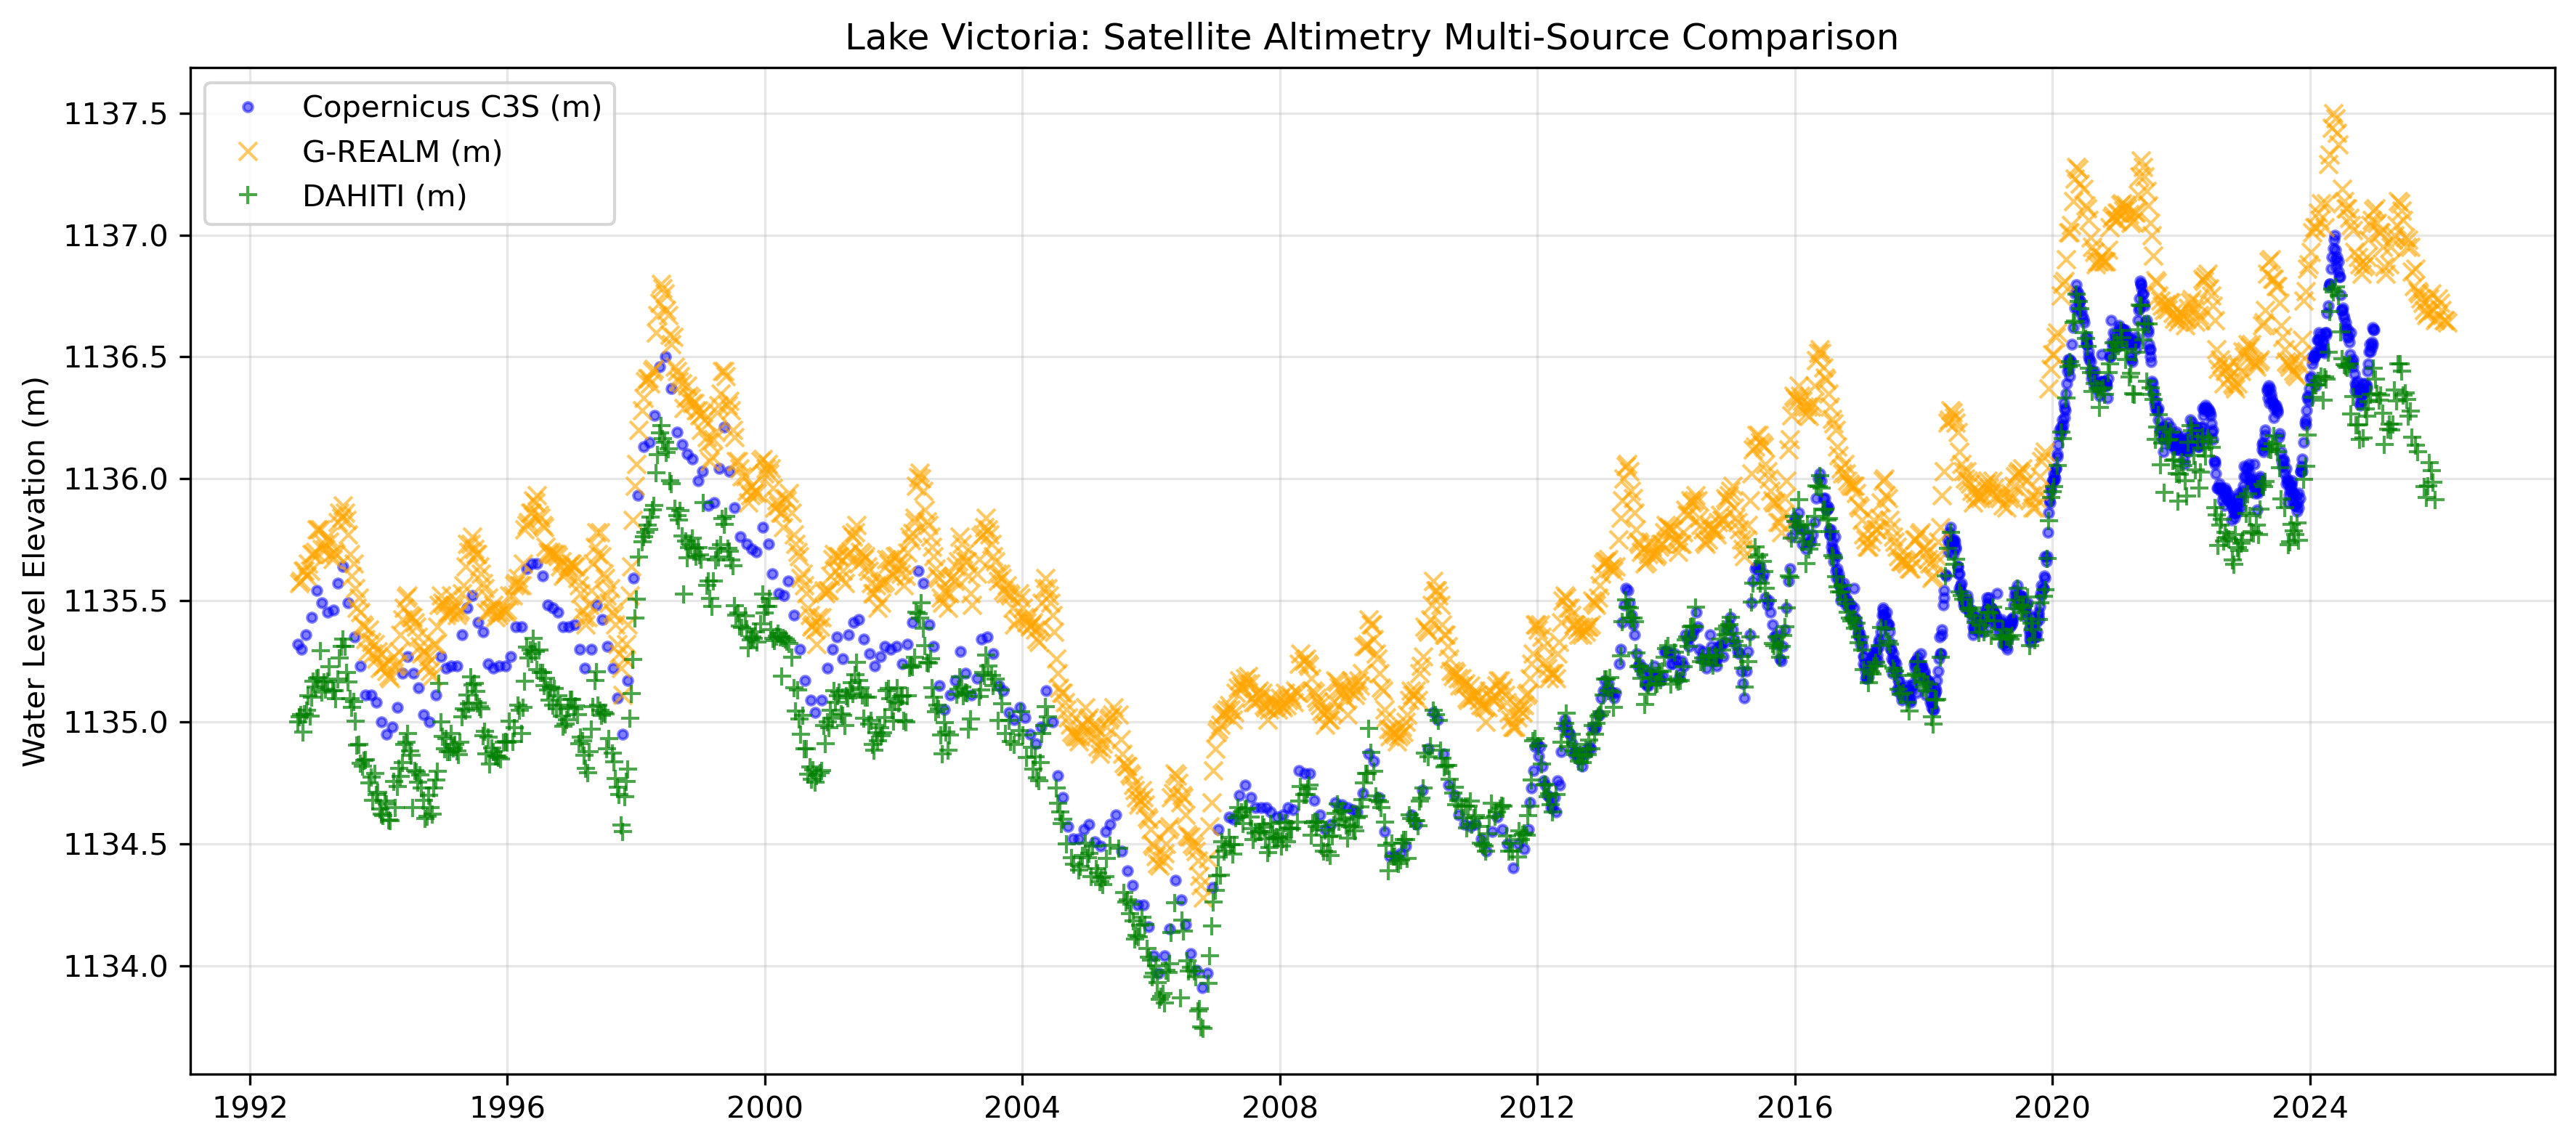

In [6]:
# Merge all data and visualise
print("4. Merging datasets")
# Join all three datasets on their date indices
df_victoria_merged = df_dahiti_daily[['DAHITI_Level_m']].join(df_grealm, how='outer') \
                                                        .join(df_cop_daily, how='outer')

# Drop dates where zero data from any of the three sources
df_victoria_merged.dropna(how='all', inplace=True)

print("\n--- MERGE COMPLETE ---")
print(df_victoria_merged.head())
print("\nData Density Summary (Non-Null Counts):")
print(df_victoria_merged.info())

# Plot the three datasets over each other
plt.figure(figsize=(14, 6), dpi=300)

plt.plot(df_victoria_merged.index, df_victoria_merged['Copernicus_Level_m'], color='blue', label='Copernicus C3S (m)', marker='.', linestyle='None', alpha=0.5)
plt.plot(df_victoria_merged.index, df_victoria_merged['GREALM_Level_m'], color='orange', label='G-REALM (m)', marker='x', linestyle='None', alpha=0.6)
plt.plot(df_victoria_merged.index, df_victoria_merged['DAHITI_Level_m'], color='green', label='DAHITI (m)', marker='+', linestyle='None', alpha=0.7)

plt.title('Lake Victoria: Satellite Altimetry Multi-Source Comparison')
plt.ylabel('Water Level Elevation (m)')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.savefig(out('Victoria_Multi_Source_Comparison.pdf'), bbox_inches='tight')
plt.show()

In [7]:
print("\n--- EXPORTING TO EXCEL ---")

if 'Reservoir' not in df_victoria_merged.columns:
    df_victoria_merged.insert(0, 'Reservoir', 'Lake Victoria')

# Name the index 'Date' before resetting it
df_victoria_merged.index.name = 'Date'

# reset index
df_excel = df_victoria_merged.reset_index()

# Format the Date column to drop the 00:00:00 time
df_excel['Date'] = pd.to_datetime(df_excel['Date']).dt.date

# Export
excel_filename = out('African_Great_Lakes_Water_Levels.xlsx')
df_excel.to_excel(excel_filename, index=False, sheet_name='Water_Levels')

print(f"Excel file created: {excel_filename}")


--- EXPORTING TO EXCEL ---
Excel file created: Code Outputs/Lake Level Outputs/African_Great_Lakes_Water_Levels.xlsx


COLLATING LAKE TANGANYIKA WATER LEVEL DATA
1. Loading DAHITI data
2. Loading G-REALM data
3. Loading Copernicus data
4. Merging datasets

--- MERGE COMPLETE ---
            DAHITI_Level_m  GREALM_Level_m  Copernicus_Level_m
1992-10-01             NaN          769.83                 NaN
1992-10-11             NaN          769.77                 NaN
1992-10-17             NaN             NaN              769.76
1992-10-21         771.304          769.90                 NaN
1992-10-31             NaN          769.81                 NaN

Data Density Summary (Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2255 entries, 1992-10-01 to 2026-02-22
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DAHITI_Level_m      859 non-null    float64
 1   GREALM_Level_m      1196 non-null   float64
 2   Copernicus_Level_m  1132 non-null   float64
dtypes: float64(3)
memory usage: 70.5 KB
None


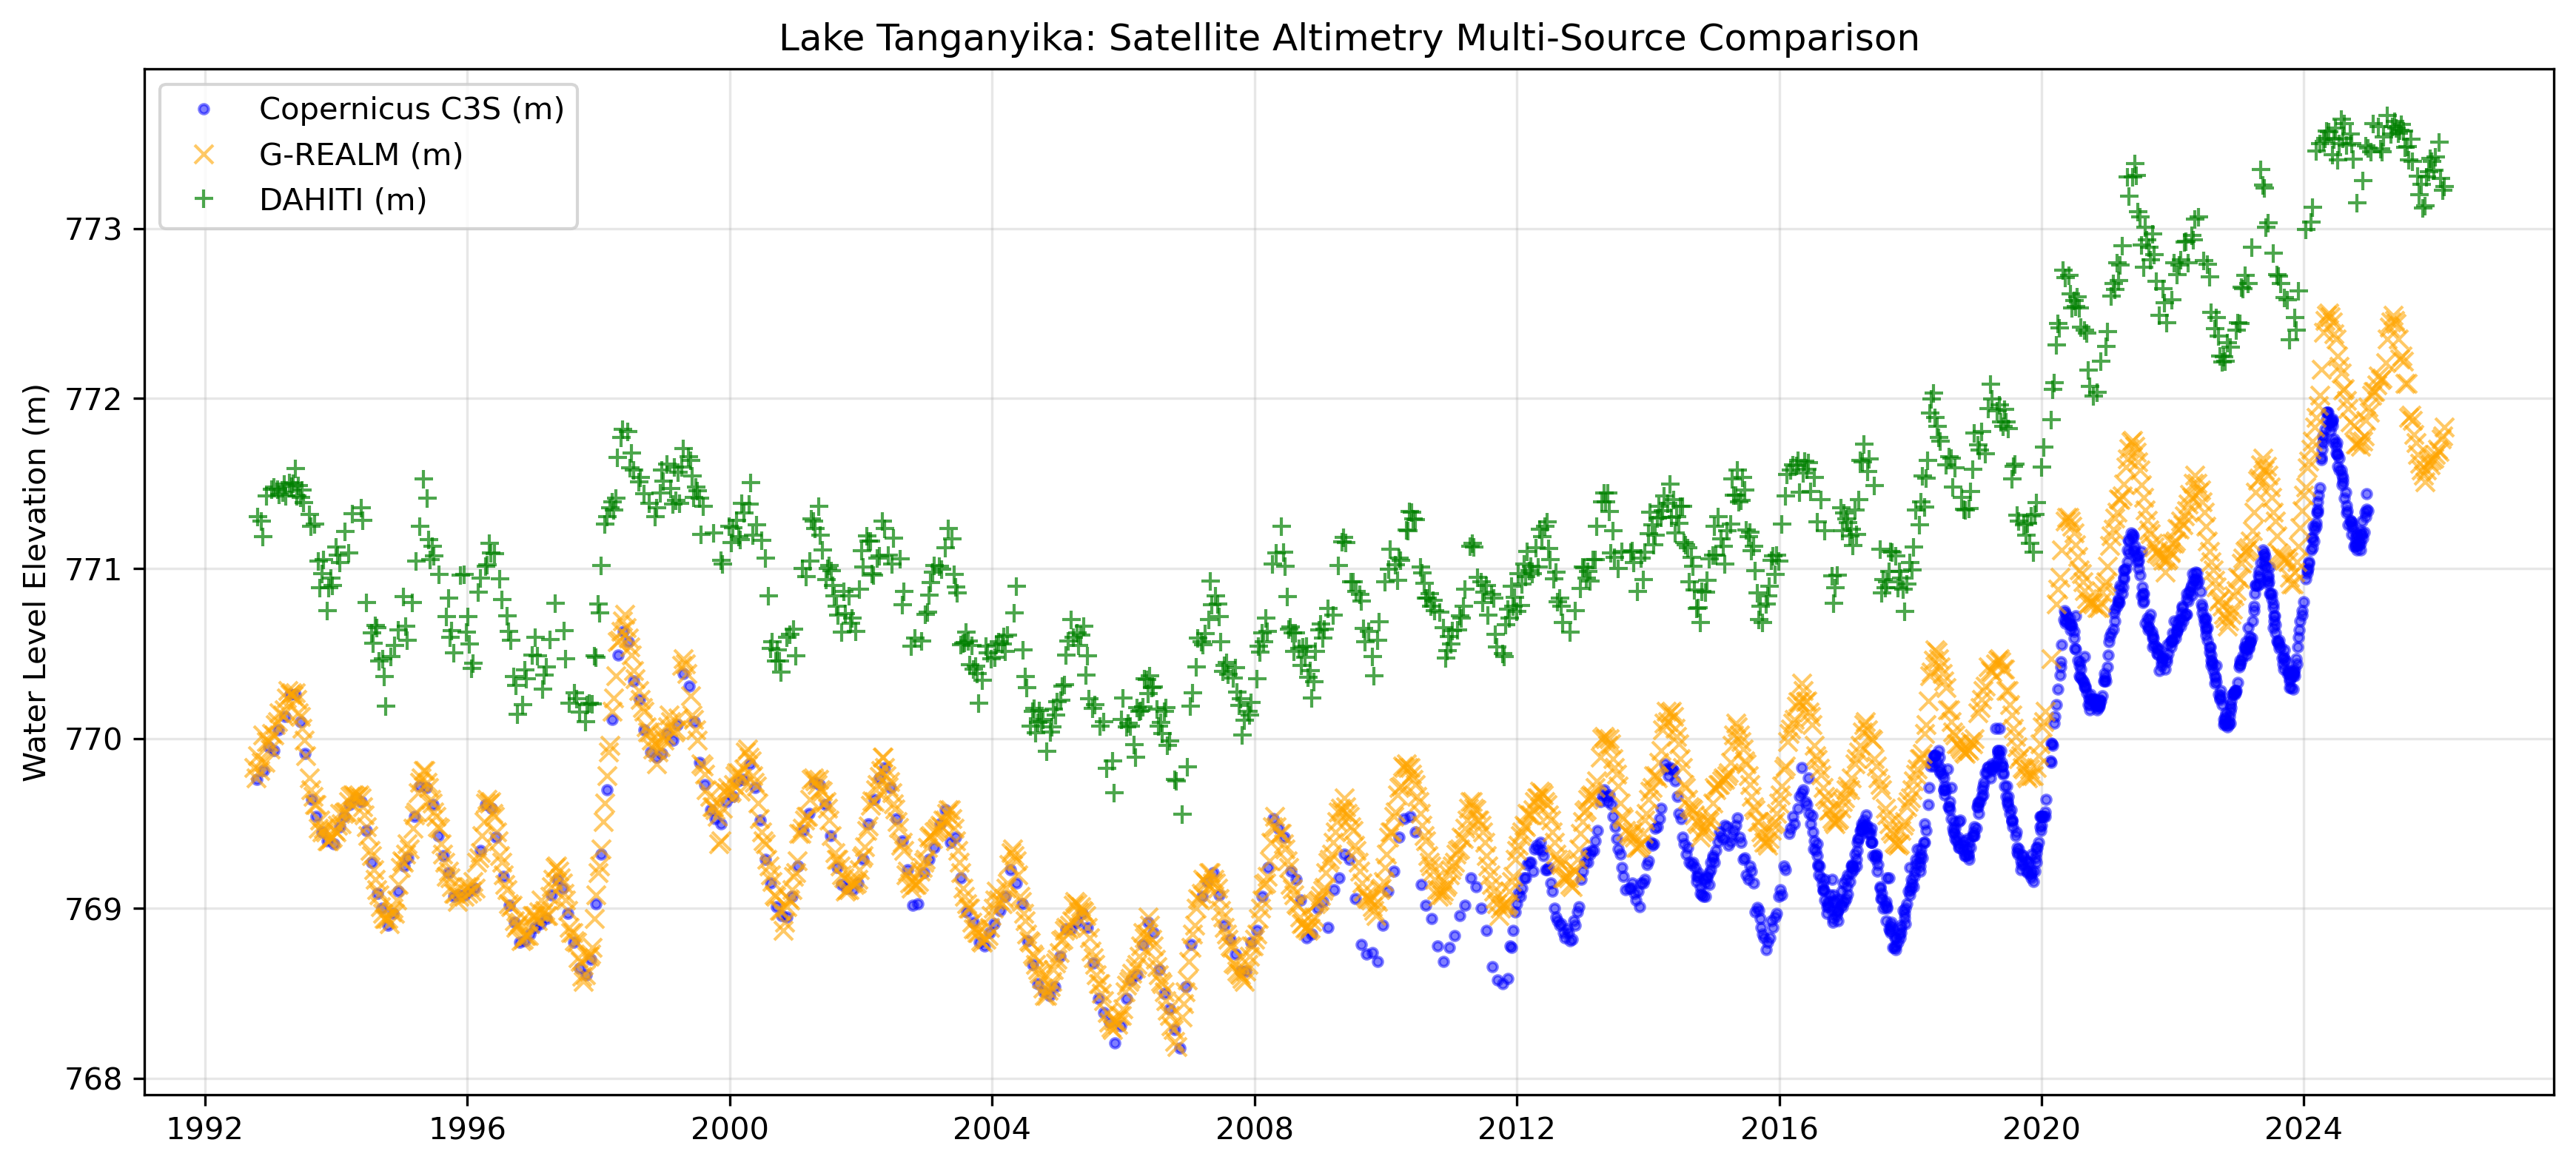

In [8]:
print("COLLATING LAKE TANGANYIKA WATER LEVEL DATA")

# Load dahiti
dahiti_text_tanganyika = """datetime;wse;wse_u
1992-10-21 02:53:51;771.304;0.001
1992-11-09 22:50:54;771.277;0.001
1992-11-19 20:49:26;771.189;0.000
1992-12-09 16:46:29;771.427;0.000
1993-01-08 10:42:04;771.466;0.001
1993-01-18 08:40:36;771.479;0.001
1993-02-07 04:37:39;771.467;0.001
1993-02-17 02:36:09;771.436;0.000
1993-03-08 22:33:12;771.448;0.000
1993-03-18 20:31:44;771.495;0.000
1993-03-28 18:30:16;771.427;0.003
1993-04-17 14:27:19;771.505;0.000
1993-04-27 12:25:51;771.484;0.001
1993-05-07 10:24:22;771.500;0.001
1993-05-17 08:22:55;771.589;0.000
1993-05-27 06:21:25;771.425;0.001
1993-06-06 04:19:57;771.489;0.001
1993-06-16 02:18:29;771.417;0.001
1993-06-26 00:17:00;771.461;0.001
1993-07-05 22:15:29;771.389;0.001
1993-08-04 16:11:01;771.317;0.000
1993-08-14 14:09:33;771.248;0.002
1993-09-03 10:06:36;771.261;0.000
1993-09-23 06:03:40;771.044;0.001
1993-10-03 04:02:11;770.889;0.000
1993-10-13 02:00:42;770.969;0.000
1993-10-22 23:59:14;771.054;0.000
1993-11-11 19:56:20;770.753;0.003
1993-11-21 17:54:48;770.889;0.001
1993-12-01 15:53:20;770.945;0.001
1993-12-11 13:51:53;770.899;0.000
1993-12-31 09:48:54;771.128;0.000
1994-01-10 07:47:24;771.080;0.001
1994-01-20 05:45:54;771.037;0.000
1994-02-18 23:41:30;771.216;0.000
1994-03-10 19:38:33;771.093;0.000
1994-03-30 15:35:35;771.321;0.000
1994-05-19 05:28:12;771.357;0.001
1994-05-29 03:26:44;771.285;0.001
1994-06-17 23:23:48;770.800;0.000
1994-07-17 17:19:24;770.623;0.000
1994-07-27 15:17:56;770.561;0.001
1994-08-06 13:16:26;770.663;0.000
1994-08-16 11:14:56;770.651;0.000
1994-08-26 09:13:27;770.454;0.000
1994-09-15 05:10:30;770.467;0.001
1994-09-25 03:09:02;770.366;0.000
1994-10-05 01:07:31;770.192;0.000
1994-11-03 19:03:07;770.480;0.000
1994-11-23 15:00:11;770.548;0.001
1994-12-13 10:57:14;770.637;0.000
1995-01-12 04:52:49;770.834;0.001
1995-01-22 02:51:22;770.660;0.000
1995-02-01 00:49:53;770.578;0.002
1995-03-02 18:45:31;770.799;0.001
1995-03-22 14:42:29;771.042;0.001
1995-04-11 10:39:30;771.247;0.001
1995-05-01 06:36:34;771.525;0.000
1995-05-21 02:33:35;771.413;0.000
1995-05-31 00:32:09;771.170;0.000
1995-06-09 22:30:40;771.051;0.000
1995-06-19 20:29:13;771.131;0.000
1995-06-29 18:27:44;771.072;0.000
1995-07-29 12:23:20;770.966;0.000
1995-09-07 04:17:24;770.715;0.001
1995-09-17 02:15:55;770.828;0.001
1995-09-27 00:14:28;770.595;0.000
1995-10-06 22:12:59;770.635;0.000
1995-10-16 20:11:35;770.503;0.004
1995-11-25 12:05:37;770.960;0.000
1995-12-15 08:02:38;770.964;0.000
1995-12-25 06:01:11;770.627;0.001
1996-01-04 03:59:39;770.719;0.001
1996-01-14 01:58:09;770.555;0.000
1996-01-23 23:56:43;770.413;0.001
1996-02-02 21:55:17;770.442;0.000
1996-03-03 15:50:53;770.863;0.001
1996-03-13 13:49:23;770.942;0.001
1996-04-12 07:44:59;771.014;0.000
1996-04-22 05:43:31;771.024;0.000
1996-05-02 03:42:01;771.150;0.001
1996-05-12 01:40:32;771.091;0.001
1996-05-31 21:37:35;771.089;0.001
1996-06-30 15:33:11;770.940;0.000
1996-07-10 13:31:41;770.818;0.000
1996-08-09 07:27:14;770.723;0.000
1996-08-19 05:25:46;770.632;0.000
1996-08-29 03:24:16;770.578;0.004
1996-09-17 23:21:22;770.365;0.001
1996-09-27 21:19:53;770.312;0.000
1996-10-07 19:18:24;770.142;0.001
1996-11-06 13:13:59;770.201;0.000
1996-11-16 11:12:34;770.405;0.003
1996-11-26 09:11:01;770.351;0.001
1996-12-26 03:06:36;770.492;0.000
1997-01-14 23:03:39;770.597;0.001
1997-01-24 21:02:12;770.486;0.000
1997-02-23 14:57:50;770.292;0.001
1997-03-05 12:56:19;770.375;0.000
1997-03-15 10:54:50;770.419;0.001
1997-04-04 06:51:54;770.581;0.000
1997-05-04 00:47:29;770.795;0.000
1997-06-22 14:40:07;770.634;0.001
1997-07-02 12:38:38;770.470;0.000
1997-07-22 08:35:41;770.209;0.000
1997-08-21 02:31:12;770.268;0.001
1997-08-31 00:29:44;770.235;0.007
1997-09-19 20:26:49;770.157;0.000
1997-10-19 14:22:23;770.099;0.002
1997-10-29 12:20:56;770.199;0.002
1997-11-08 10:19:25;770.210;0.002
1997-11-28 06:16:28;770.205;0.001
1997-12-08 04:15:00;770.487;0.001
1997-12-18 02:13:32;770.478;0.001
1997-12-28 00:12:02;770.790;0.001
1998-01-06 22:10:33;770.741;0.005
1998-01-16 20:09:06;771.019;0.000
1998-02-05 16:06:10;771.261;0.000
1998-02-15 14:04:42;771.304;0.000
1998-03-07 10:01:47;771.357;0.001
1998-03-17 08:00:17;771.394;0.000
1998-03-27 05:58:50;771.344;0.001
1998-04-06 03:57:21;771.413;0.001
1998-04-16 01:55:52;771.653;0.001
1998-05-05 21:52:56;771.769;0.004
1998-05-15 19:51:28;771.820;0.000
1998-06-14 13:47:03;771.806;0.000
1998-06-24 11:45:33;771.591;0.000
1998-07-04 09:44:04;771.680;0.000
1998-07-14 07:42:35;771.580;0.000
1998-08-13 01:38:10;771.510;0.002
1998-08-22 23:36:42;771.535;0.001
1998-09-11 19:33:44;771.438;0.001
1998-10-11 13:29:18;771.384;0.002
1998-11-10 07:24:50;771.305;0.001
1998-11-20 05:23:22;771.355;0.000
1998-12-10 01:20:27;771.442;0.000
1998-12-19 23:18:58;771.580;0.001
1998-12-29 21:17:30;771.512;0.000
1999-01-18 17:14:33;771.614;0.000
1999-02-07 13:11:36;771.472;0.002
1999-02-17 11:10:08;771.377;0.000
1999-02-27 09:08:40;771.597;0.000
1999-03-09 07:07:10;771.400;0.001
1999-03-19 05:05:41;771.568;0.001
1999-03-29 03:04:14;771.384;0.000
1999-04-08 01:02:45;771.597;0.000
1999-04-17 23:01:16;771.707;0.001
1999-05-17 16:56:51;771.657;0.001
1999-05-27 14:55:22;771.637;0.001
1999-06-06 12:53:52;771.545;0.001
1999-06-16 10:52:25;771.420;0.001
1999-06-26 08:50:56;771.477;0.002
1999-07-06 06:49:28;771.457;0.002
1999-07-16 04:47:59;771.412;0.002
1999-07-26 02:46:31;771.199;0.001
1999-08-05 00:45:03;771.365;0.000
1999-10-03 12:36:10;771.207;0.001
1999-11-12 04:30:15;771.050;0.000
1999-11-22 02:28:47;771.027;0.001
1999-12-31 18:22:52;771.249;0.002
2000-01-10 16:21:25;771.154;0.000
2000-01-20 14:19:55;771.241;0.001
2000-02-09 10:17:00;771.285;0.001
2000-02-19 08:15:32;771.189;0.000
2000-02-29 06:14:04;771.170;0.000
2000-03-10 04:12:34;771.383;0.000
2000-03-20 02:11:06;771.327;0.001
2000-04-18 20:06:37;771.380;0.001
2000-04-28 18:05:09;771.504;0.001
2000-05-08 16:03:41;771.195;0.000
2000-05-28 12:00:44;771.255;0.000
2000-06-27 05:56:16;771.165;0.000
2000-07-17 01:53:20;771.063;0.000
2000-08-05 21:50:23;770.840;0.000
2000-08-15 19:48:57;770.530;0.000
2000-08-25 17:47:29;770.567;0.002
2000-09-14 13:44:32;770.454;0.000
2000-09-24 11:43:01;770.520;0.000
2000-10-04 09:41:34;770.456;0.001
2000-10-14 07:40:04;770.392;0.000
2000-11-13 01:35:38;770.596;0.001
2000-12-02 21:32:42;770.612;0.000
2000-12-22 17:29:46;770.641;0.001
2001-01-01 15:28:15;770.488;0.000
2001-02-10 07:22:21;771.000;0.000
2001-03-02 03:19:25;770.951;0.000
2001-03-21 23:16:26;771.045;0.001
2001-03-31 21:14:58;771.291;0.001
2001-04-10 19:13:31;771.280;0.001
2001-04-20 17:12:01;771.234;0.001
2001-05-10 13:09:04;771.364;0.000
2001-05-20 11:07:35;771.197;0.000
2001-05-30 09:06:07;771.111;0.000
2001-06-19 05:03:11;770.937;0.000
2001-06-29 03:01:41;771.001;0.001
2001-07-09 01:00:11;771.018;0.001
2001-07-18 22:58:44;770.985;0.001
2001-07-28 20:57:15;770.899;0.000
2001-08-07 18:55:46;770.837;0.000
2001-08-17 16:54:18;770.776;0.000
2001-08-27 14:52:50;770.725;0.000
2001-09-16 10:49:49;770.626;0.000
2001-09-26 08:48:22;770.865;0.000
2001-10-06 06:46:54;770.733;0.001
2001-10-26 02:43:57;770.839;0.000
2001-11-05 00:42:27;770.680;0.000
2001-11-14 22:40:59;770.710;0.000
2001-12-04 18:38:03;770.632;0.001
2001-12-24 14:35:07;770.878;0.000
2002-01-03 12:33:38;771.106;0.000
2002-01-13 10:32:08;771.010;0.000
2002-02-02 00:00:00;771.191;0.000
2002-02-12 00:00:00;771.161;0.002
2002-02-22 00:00:00;771.160;0.000
2002-03-04 00:00:00;770.971;0.000
2002-03-13 00:00:00;770.962;0.001
2002-04-02 00:00:00;771.060;0.000
2002-04-12 00:00:00;771.073;0.000
2002-05-02 00:00:00;771.280;0.000
2002-05-12 00:00:00;771.236;0.000
2002-06-01 00:00:00;771.078;0.000
2002-06-21 00:00:00;771.026;0.000
2002-07-01 00:00:00;771.178;0.001
2002-08-09 00:00:00;771.056;0.000
2002-08-19 00:00:00;770.785;0.001
2002-08-29 11:57:03;770.865;0.002
2002-10-08 03:51:09;770.541;0.002
2002-10-27 23:48:11;770.589;0.003
2002-12-06 15:42:18;770.574;0.001
2002-12-26 11:39:22;770.730;0.002
2003-01-05 09:37:52;770.745;0.001
2003-01-15 07:36:26;770.845;0.001
2003-01-25 05:34:57;770.919;0.003
2003-02-04 03:33:27;770.977;0.003
2003-02-14 01:31:56;771.018;0.002
2003-03-15 19:27:32;771.014;0.000
2003-03-25 17:26:05;770.994;0.000
2003-04-14 13:23:06;771.123;0.001
2003-05-04 09:20:13;771.237;0.003
2003-05-24 05:17:16;771.175;0.001
2003-06-03 03:15:47;770.965;0.001
2003-06-13 01:14:18;770.893;0.001
2003-06-22 23:12:48;770.855;0.001
2003-07-12 19:09:53;770.551;0.001
2003-07-22 17:08:26;770.560;0.000
2003-08-01 15:06:57;770.565;0.001
2003-08-11 13:05:28;770.624;0.001
2003-08-21 11:04:00;770.574;0.003
2003-08-31 09:02:33;770.434;0.001
2003-09-10 07:01:04;770.546;0.000
2003-09-20 04:59:35;770.410;0.000
2003-09-30 02:58:05;770.426;0.001
2003-10-10 00:56:37;770.381;0.005
2003-10-19 22:55:10;770.207;0.002
2003-11-08 18:52:11;770.344;0.004
2003-11-28 14:49:15;770.543;0.000
2003-12-08 12:47:48;770.505;0.000
2003-12-28 08:44:52;770.471;0.002
2004-01-17 04:42:00;770.476;0.003
2004-01-27 02:40:27;770.553;0.001
2004-02-06 00:38:59;770.569;0.001
2004-02-25 20:35:58;770.555;0.000
2004-03-06 18:34:31;770.601;0.001
2004-03-16 16:33:06;770.513;0.002
2004-03-26 14:31:41;770.609;0.003
2004-05-05 06:25:45;770.737;0.001
2004-05-15 04:24:17;770.896;0.002
2004-06-23 20:18:20;770.522;0.000
2004-07-03 18:16:54;770.365;0.002
2004-07-13 16:15:27;770.299;0.003
2004-08-02 12:12:33;770.073;0.002
2004-08-12 10:11:03;770.160;0.001
2004-08-22 08:09:35;770.179;0.000
2004-09-01 06:08:07;770.034;0.000
2004-09-11 04:06:38;770.096;0.002
2004-09-21 02:05:07;770.166;0.000
2004-10-01 00:03:37;770.101;0.001
2004-10-10 22:02:09;770.110;0.001
2004-10-30 17:59:15;769.925;0.002
2004-11-19 13:56:20;770.039;0.001
2004-11-29 11:54:50;770.069;0.001
2004-12-09 09:53:23;770.172;0.001
2004-12-19 07:51:55;770.139;0.001
2004-12-29 05:50:26;770.217;0.002
2005-01-18 01:47:24;770.226;0.001
2005-01-27 23:45:58;770.308;0.001
2005-02-06 21:44:30;770.316;0.001
2005-02-16 19:43:01;770.489;0.001
2005-02-26 17:41:35;770.574;0.000
2005-03-18 13:38:40;770.700;0.000
2005-03-28 11:37:11;770.597;0.002
2005-04-17 07:34:15;770.623;0.001
2005-04-27 05:32:47;770.547;0.001
2005-05-07 03:31:18;770.609;0.001
2005-05-26 23:28:21;770.661;0.002
2005-06-05 21:26:55;770.373;0.000
2005-06-15 19:25:26;770.487;0.001
2005-06-25 17:23:59;770.236;0.000
2005-07-15 13:21:03;770.177;0.002
2005-07-25 11:19:34;770.201;0.001
2005-08-24 05:15:11;770.073;0.001
2005-09-13 01:12:11;770.101;0.002
2005-10-02 21:09:17;769.825;0.003
2005-11-01 15:04:52;769.870;0.002
2005-11-11 13:03:26;769.683;0.001
2005-12-21 04:57:31;770.112;0.000
2005-12-31 02:56:01;770.239;0.001
2006-01-19 22:53:04;770.070;0.001
2006-01-29 20:51:37;770.089;0.000
2006-02-08 18:50:10;770.075;0.000
2006-02-28 14:47:15;769.965;0.002
2006-03-10 12:45:48;769.889;0.001
2006-03-20 10:44:19;770.183;0.002
2006-03-30 08:42:50;770.161;0.001
2006-04-09 06:41:22;770.166;0.000
2006-04-19 04:39:53;770.186;0.001
2006-04-29 02:38:25;770.352;0.001
2006-05-09 00:36:55;770.348;0.002
2006-05-18 22:35:27;770.264;0.001
2006-05-28 20:33:59;770.368;0.001
2006-06-07 18:32:31;770.300;0.002
2006-06-17 16:31:01;770.302;0.002
2006-07-07 12:28:05;770.172;0.002
2006-07-17 10:26:37;770.074;0.002
2006-07-27 08:25:10;770.095;0.004
2006-08-06 06:23:41;770.030;0.002
2006-08-16 04:22:13;770.159;0.001
2006-08-26 02:20:45;770.183;0.000
2006-09-05 00:19:16;769.961;0.004
2006-09-14 22:17:50;769.984;0.000
2006-10-14 16:13:23;769.758;0.001
2006-10-24 14:11:56;769.751;0.002
2006-11-23 08:07:33;769.555;0.000
2006-12-23 02:03:06;769.834;0.001
2007-01-11 22:00:11;770.189;0.002
2007-01-21 19:58:42;770.268;0.004
2007-02-10 15:55:45;770.423;0.003
2007-02-20 13:54:18;770.591;0.001
2007-03-12 09:51:24;770.567;0.002
2007-03-22 07:49:56;770.551;0.001
2007-04-01 05:48:26;770.616;0.000
2007-04-21 01:45:28;770.698;0.002
2007-04-30 23:43:59;770.927;0.001
2007-05-10 21:42:31;770.785;0.001
2007-05-30 17:39:34;770.841;0.001
2007-06-09 15:38:07;770.791;0.000
2007-06-19 13:36:38;770.716;0.001
2007-06-29 11:35:11;770.569;0.000
2007-07-09 09:33:41;770.396;0.000
2007-07-19 07:32:14;770.431;0.000
2007-07-29 05:30:45;770.448;0.001
2007-08-08 03:29:16;770.377;0.002
2007-09-06 21:24:53;770.357;0.003
2007-09-16 19:23:24;770.416;0.000
2007-09-26 17:21:56;770.275;0.003
2007-10-06 15:20:30;770.194;0.002
2007-10-16 13:19:00;770.232;0.001
2007-10-26 11:17:33;770.022;0.002
2007-11-05 09:16:04;770.109;0.001
2007-11-25 05:13:05;770.160;0.000
2007-12-05 03:11:40;770.139;0.001
2007-12-15 01:10:08;770.213;0.002
2008-01-13 19:05:45;770.351;0.001
2008-01-23 17:04:17;770.541;0.000
2008-02-02 15:02:50;770.507;0.001
2008-02-12 13:01:23;770.622;0.002
2008-02-22 10:59:54;770.570;0.001
2008-03-03 08:58:27;770.707;0.000
2008-03-13 06:56:59;770.631;0.001
2008-04-12 00:52:30;771.027;0.002
2008-05-01 20:49:33;771.091;0.000
2008-05-31 14:45:09;771.247;0.001
2008-06-10 12:43:41;771.097;0.001
2008-06-20 10:42:11;771.015;0.001
2008-06-30 08:40:45;770.833;0.000
2008-07-10 06:39:16;770.642;0.000
2008-07-20 04:38:16;770.658;0.001
2008-07-30 02:36:45;770.622;0.000
2008-08-09 00:35:44;770.513;0.001
2008-08-18 22:34:16;770.623;0.002
2008-09-07 18:30:53;770.529;0.001
2008-09-17 16:29:25;770.431;0.000
2008-09-27 14:28:01;770.538;0.001
2008-10-07 12:26:27;770.477;0.001
2008-10-17 10:25:02;770.544;0.000
2008-10-27 08:23:31;770.359;0.001
2008-11-06 06:22:02;770.401;0.000
2008-11-16 04:20:31;770.239;0.000
2008-11-26 02:18:57;770.335;0.002
2008-12-06 00:17:40;770.512;0.001
2008-12-25 20:14:40;770.637;0.001
2009-01-04 18:13:17;770.675;0.001
2009-01-14 16:11:39;770.590;0.000
2009-01-24 14:10:16;770.642;0.000
2009-02-13 10:07:47;770.763;0.002
2009-03-15 04:03:22;770.725;0.001
2009-04-13 21:58:54;771.016;0.001
2009-05-03 17:55:56;771.159;0.002
2009-05-13 15:54:28;771.185;0.002
2009-05-23 13:53:01;771.152;0.001
2009-06-22 07:48:37;770.921;0.001
2009-07-02 05:47:08;770.921;0.000
2009-07-22 01:44:11;770.866;0.002
2009-08-10 21:41:13;770.848;0.002
2009-08-20 19:39:43;770.810;0.003
2009-08-30 17:38:15;770.648;0.001
2009-09-09 15:36:48;770.567;0.001
2009-09-29 11:33:52;770.630;0.000
2009-10-19 07:30:56;770.480;0.000
2009-10-29 05:29:27;770.370;0.002
2009-11-18 01:26:30;770.579;0.000
2009-11-27 23:25:00;770.688;0.002
2009-12-27 17:20:35;770.923;0.002
2010-01-16 13:17:40;770.996;0.001
2010-01-26 11:16:11;771.115;0.002
2010-02-25 05:11:47;771.020;0.001
2010-03-07 03:10:18;770.929;0.001
2010-03-17 01:08:48;771.060;0.001
2010-03-26 23:07:19;771.047;0.000
2010-04-25 17:02:54;771.228;0.001
2010-05-05 15:01:25;771.224;0.002
2010-05-15 12:59:56;771.334;0.001
2010-05-25 10:58:28;771.332;0.001
2010-06-04 08:57:00;771.291;0.001
2010-06-14 06:55:32;771.289;0.000
2010-07-14 00:51:05;771.009;0.001
2010-07-23 22:49:35;770.975;0.000
2010-08-02 20:48:08;770.914;0.002
2010-08-12 18:46:40;770.826;0.000
2010-08-22 16:45:12;770.824;0.001
2010-09-01 14:43:44;770.850;0.002
2010-09-11 12:42:16;770.776;0.001
2010-09-21 10:40:47;770.813;0.002
2010-10-01 08:39:19;770.752;0.000
2010-10-31 02:34:51;770.744;0.000
2010-11-19 22:31:55;770.650;0.000
2010-11-29 20:30:28;770.475;0.001
2010-12-09 18:28:59;770.515;0.000
2010-12-19 16:27:31;770.598;0.000
2010-12-29 14:26:02;770.558;0.001
2011-01-08 12:24:34;770.636;0.002
2011-02-07 06:20:07;770.638;0.001
2011-02-17 04:18:38;770.723;0.000
2011-02-27 02:17:09;770.708;0.001
2011-03-09 00:15:40;770.778;0.001
2011-03-18 22:14:12;770.880;0.003
2011-04-17 16:09:49;771.131;0.003
2011-04-27 14:08:19;771.148;0.001
2011-05-07 12:06:51;771.128;0.001
2011-05-27 08:03:52;770.950;0.001
2011-06-16 04:00:57;770.920;0.003
2011-06-26 01:59:29;770.799;0.002
2011-07-05 23:58:01;770.859;0.003
2011-07-15 21:56:32;770.901;0.001
2011-07-25 19:55:03;770.726;0.001
2011-08-14 15:52:05;770.847;0.003
2011-08-24 13:50:35;770.826;0.000
2011-09-03 11:49:08;770.611;0.002
2011-09-13 09:47:39;770.540;0.003
2011-10-13 03:43:14;770.501;0.000
2011-10-23 01:41:45;770.484;0.002
2011-11-01 23:40:16;770.671;0.001
2011-11-11 21:38:48;770.759;0.002
2011-11-21 19:37:21;770.710;0.002
2011-12-01 17:35:52;770.896;0.000
2011-12-11 15:34:23;770.780;0.003
2011-12-21 13:32:54;770.831;0.002
2011-12-31 11:31:28;770.748;0.000
2012-01-10 09:29:59;770.969;0.002
2012-01-20 07:28:31;770.783;0.000
2012-01-30 05:27:02;770.907;0.002
2012-02-09 03:25:32;771.027;0.001
2012-02-19 01:24:05;770.954;0.001
2012-02-28 23:22:35;771.099;0.001
2012-03-09 21:21:05;770.986;0.000
2012-03-19 19:19:38;771.014;0.001
2012-03-29 17:18:12;770.969;0.002
2012-04-18 13:15:13;771.120;0.003
2012-04-28 11:13:45;771.011;0.000
2012-05-08 09:12:16;771.230;0.003
2012-05-18 07:10:47;771.188;0.000
2012-06-07 03:07:50;771.250;0.000
2012-06-17 01:06:23;771.274;0.000
2012-06-26 23:04:55;771.116;0.001
2012-07-06 21:03:26;771.052;0.002
2012-07-26 17:00:27;770.941;0.001
2012-08-05 14:58:59;770.978;0.001
2012-08-15 12:57:31;770.805;0.002
2012-08-25 10:56:02;770.825;0.001
2012-09-04 08:54:35;770.780;0.002
2012-09-14 06:53:05;770.684;0.000
2012-10-23 22:47:09;770.627;0.001
2012-11-22 16:42:45;770.752;0.002
2012-12-22 10:38:21;770.883;0.001
2013-01-01 08:36:53;771.010;0.002
2013-01-11 06:35:25;771.005;0.003
2013-01-21 04:33:59;770.942;0.002
2013-01-31 02:32:29;770.981;0.001
2013-02-10 00:30:58;770.927;0.001
2013-03-01 20:28:02;771.054;0.001
2013-03-11 18:26:33;771.054;0.001
2013-03-21 16:25:06;771.248;0.000
2013-04-20 10:20:41;771.393;0.000
2013-04-30 08:19:12;771.444;0.004
2013-05-10 06:17:43;771.393;0.003
2013-05-20 04:16:12;771.443;0.000
2013-05-30 02:14:47;771.336;0.000
2013-06-09 00:13:19;771.090;0.002
2013-06-18 22:11:51;771.221;0.000
2013-06-28 20:10:21;771.064;0.002
2013-07-18 16:07:24;771.002;0.000
2013-08-07 12:04:26;771.101;0.003
2013-09-26 01:57:05;771.095;0.000
2013-10-05 23:55:35;771.104;0.002
2013-10-15 21:54:09;771.035;0.001
2013-11-04 17:51:11;770.864;0.002
2013-11-24 13:48:15;771.063;0.001
2013-12-04 11:46:47;770.935;0.001
2013-12-14 09:45:18;771.098;0.003
2014-01-03 05:42:22;771.203;0.000
2014-01-13 03:40:54;771.331;0.000
2014-01-23 01:39:26;771.257;0.002
2014-02-01 23:37:56;771.141;0.000
2014-02-11 21:36:30;771.197;0.003
2014-02-21 19:35:00;771.295;0.003
2014-03-03 17:33:30;771.364;0.000
2014-03-13 15:32:04;771.299;0.002
2014-03-23 13:30:37;771.340;0.002
2014-04-02 11:29:08;771.425;0.002
2014-04-22 07:26:09;771.382;0.001
2014-05-02 05:24:42;771.497;0.000
2014-05-12 03:23:15;771.301;0.000
2014-05-22 01:21:45;771.404;0.001
2014-05-31 23:20:18;771.209;0.002
2014-06-10 21:18:50;771.307;0.002
2014-06-20 19:17:20;771.266;0.001
2014-06-30 17:15:51;771.365;0.002
2014-07-10 15:14:21;771.365;0.002
2014-07-20 13:12:54;771.153;0.003
2014-07-30 11:11:27;771.138;0.001
2014-08-09 09:10:00;771.121;0.003
2014-08-19 07:08:30;770.922;0.001
2014-08-29 05:07:02;771.067;0.003
2014-09-08 03:05:34;771.012;0.001
2014-09-18 01:04:06;770.875;0.001
2014-09-27 23:02:38;770.764;0.000
2014-10-07 21:01:07;770.769;0.002
2014-10-17 18:59:38;770.683;0.001
2014-10-27 16:58:11;770.866;0.001
2014-11-16 12:55:15;770.859;0.001
2014-11-26 10:53:46;770.929;0.001
2014-12-06 08:52:16;771.058;0.001
2014-12-26 04:49:22;771.080;0.002
2015-01-05 02:47:53;771.249;0.002
2015-01-15 00:46:25;771.079;0.001
2015-01-24 22:44:56;771.305;0.002
2015-02-13 18:41:59;771.174;0.001
2015-02-23 16:40:29;771.129;0.001
2015-03-05 14:39:00;771.026;0.000
2015-03-15 12:37:34;771.220;0.002
2015-04-04 08:34:39;771.262;0.002
2015-04-14 06:33:12;771.526;0.003
2015-04-24 04:31:42;771.429;0.002
2015-05-04 02:30:14;771.433;0.001
2015-05-14 00:28:41;771.577;0.002
2015-05-23 22:27:14;771.390;0.002
2015-06-02 20:25:46;771.400;0.003
2015-06-12 18:24:20;771.537;0.001
2015-06-22 16:22:52;771.461;0.001
2015-07-02 14:21:23;771.226;0.001
2015-07-12 12:19:55;771.187;0.000
2015-07-22 10:18:26;771.213;0.001
2015-08-01 08:16:56;771.106;0.000
2015-08-11 06:15:28;771.132;0.001
2015-08-21 04:13:59;770.985;0.003
2015-08-31 02:12:30;770.856;0.000
2015-09-10 00:11:02;770.698;0.003
2015-09-19 22:09:34;770.780;0.000
2015-09-29 20:08:08;770.684;0.001
2015-10-19 16:05:11;770.791;0.001
2015-10-29 14:03:44;770.839;0.000
2015-11-08 12:02:15;770.895;0.000
2015-11-18 10:00:45;771.046;0.001
2015-11-28 07:59:17;771.072;0.002
2015-12-08 05:57:50;770.966;0.003
2015-12-18 03:56:21;771.080;0.000
2015-12-28 01:54:52;771.043;0.002
2016-01-16 21:51:54;771.262;0.001
2016-02-05 17:48:57;771.427;0.001
2016-02-15 15:47:31;771.551;0.001
2016-03-06 11:45:11;771.580;0.000
2016-03-16 09:43:07;771.609;0.000
2016-04-05 05:40:52;771.607;0.001
2016-04-15 03:39:27;771.634;0.001
2016-04-25 01:37:52;771.449;0.001
2016-05-14 21:34:57;771.561;0.002
2016-05-24 19:33:25;771.630;0.000
2016-06-03 17:32:00;771.584;0.001
2016-06-13 15:30:27;771.623;0.001
2016-06-23 13:29:06;771.451;0.000
2016-07-13 09:26:07;771.534;0.000
2016-08-02 05:23:15;771.275;0.001
2016-08-22 01:20:16;771.404;0.000
2016-09-10 21:17:14;771.222;0.001
2016-10-20 13:12:04;770.956;0.001
2016-10-30 11:10:35;770.796;0.000
2016-11-09 09:09:07;770.888;0.001
2016-11-19 07:07:38;770.961;0.002
2016-12-09 03:04:40;771.356;0.000
2016-12-19 01:03:11;771.222;0.001
2016-12-28 23:01:44;771.325;0.000
2017-01-07 21:00:14;771.292;0.001
2017-01-17 18:58:46;771.271;0.001
2017-01-27 16:57:18;771.191;0.002
2017-02-06 14:55:50;771.231;0.002
2017-02-16 12:54:22;771.135;0.000
2017-02-26 10:52:54;771.343;0.002
2017-03-08 08:51:25;771.201;0.001
2017-03-18 06:49:55;771.407;0.002
2017-03-28 04:48:27;771.634;0.001
2017-04-07 02:46:58;771.629;0.002
2017-04-17 00:45:27;771.733;0.000
2017-05-06 20:42:35;771.569;0.000
2017-05-16 18:41:06;771.644;0.000
2017-06-15 12:36:41;771.488;0.000
2017-07-15 06:32:18;771.115;0.002
2017-07-25 04:30:49;770.858;0.001
2017-08-04 02:29:19;770.933;0.000
2017-08-14 00:27:50;770.886;0.003
2017-08-23 22:26:23;770.920;0.001
2017-09-02 20:24:52;770.981;0.001
2017-09-12 18:23:24;771.101;0.004
2017-09-22 16:21:57;771.095;0.002
2017-10-12 12:19:01;771.074;0.001
2017-10-22 10:17:34;770.888;0.001
2017-11-01 08:16:05;770.984;0.001
2017-11-11 06:14:36;770.943;0.001
2017-11-21 04:13:08;770.880;0.002
2017-12-01 02:11:38;770.748;0.003
2017-12-11 00:10:10;770.910;0.000
2017-12-30 20:07:14;771.034;0.000
2018-01-09 18:05:45;770.993;0.000
2018-01-19 16:04:17;771.128;0.002
2018-01-29 14:02:48;771.344;0.001
2018-02-18 09:59:53;771.258;0.001
2018-02-28 07:58:24;771.394;0.000
2018-03-10 05:56:55;771.543;0.002
2018-03-20 03:55:26;771.360;0.000
2018-03-30 01:53:55;771.532;0.004
2018-04-08 23:52:28;771.635;0.002
2018-04-18 21:50:59;771.915;0.001
2018-04-28 19:49:32;771.996;0.001
2018-05-08 17:48:04;772.030;0.002
2018-05-18 15:46:35;771.890;0.002
2018-05-28 13:45:07;771.836;0.001
2018-06-07 11:43:39;771.772;0.001
2018-06-17 09:42:11;771.747;0.003
2018-07-17 03:37:45;771.608;0.002
2018-08-05 23:34:48;771.657;0.002
2018-08-15 21:33:17;771.648;0.001
2018-08-25 19:31:51;771.479;0.000
2018-09-04 17:30:23;771.594;0.001
2018-10-14 09:24:30;771.420;0.001
2018-10-24 07:23:01;771.350;0.001
2018-11-03 05:21:33;771.343;0.000
2018-11-23 01:18:33;771.354;0.002
2018-12-02 23:17:06;771.453;0.003
2018-12-12 21:15:36;771.583;0.001
2018-12-22 19:14:08;771.796;0.000
2019-01-11 15:11:13;771.726;0.001
2019-01-21 13:09:46;771.698;0.001
2019-01-31 11:08:19;771.805;0.002
2019-02-20 07:05:20;771.675;0.000
2019-03-12 03:02:23;771.941;0.001
2019-03-22 01:00:53;772.083;0.002
2019-03-31 22:59:23;771.995;0.000
2019-04-30 16:54:57;771.928;0.000
2019-05-10 14:53:30;771.961;0.001
2019-05-20 12:52:02;771.863;0.001
2019-05-30 10:50:35;771.837;0.000
2019-06-09 08:49:07;771.936;0.000
2019-06-19 06:47:38;771.863;0.000
2019-06-29 04:46:10;771.823;0.000
2019-07-19 00:43:11;771.528;0.002
2019-07-28 22:41:42;771.599;0.002
2019-08-07 20:40:12;771.613;0.001
2019-08-17 18:38:45;771.314;0.003
2019-08-27 16:37:18;771.277;0.003
2019-09-26 10:32:53;771.256;0.001
2019-10-06 08:31:25;771.196;0.000
2019-10-16 06:29:54;771.265;0.000
2019-10-26 04:28:27;771.146;0.002
2019-11-05 02:26:57;771.310;0.000
2019-11-15 00:25:29;771.097;0.001
2019-11-24 22:23:58;771.319;0.001
2019-12-04 20:22:29;771.388;0.001
2020-01-03 14:18:06;771.598;0.001
2020-01-13 12:16:38;771.712;0.000
2020-02-22 04:10:43;771.874;0.002
2020-03-03 02:09:13;772.053;0.001
2020-03-13 00:07:46;772.093;0.000
2020-03-22 22:06:16;772.316;0.004
2020-04-01 20:04:47;772.440;0.002
2020-04-11 18:03:22;772.417;0.003
2020-05-01 14:00:24;772.753;0.001
2020-05-11 11:58:57;772.709;0.002
2020-05-31 07:56:01;772.726;0.002
2020-06-10 05:54:31;772.614;0.001
2020-06-20 03:53:02;772.533;0.000
2020-06-30 01:51:34;772.574;0.001
2020-07-09 23:50:05;772.539;0.001
2020-07-19 21:48:35;772.597;0.002
2020-07-29 19:47:05;772.532;0.002
2020-08-08 17:45:38;772.421;0.000
2020-08-28 13:42:42;772.404;0.001
2020-09-07 11:41:15;772.386;0.001
2020-09-17 09:39:46;772.166;0.000
2020-09-27 07:38:18;772.071;0.002
2020-10-17 03:35:21;772.013;0.002
2020-11-05 23:32:22;772.038;0.001
2020-11-25 19:29:26;772.217;0.001
2020-12-25 13:25:16;772.307;0.000
2021-01-04 11:23:50;772.393;0.000
2021-01-24 07:20:50;772.603;0.000
2021-02-03 05:19:21;772.677;0.000
2021-02-13 03:17:52;772.640;0.001
2021-02-23 01:16:22;772.798;0.000
2021-03-04 23:14:41;772.692;0.001
2021-03-14 21:13:30;772.786;0.000
2021-03-24 19:11:58;772.897;0.001
2021-04-23 13:07:36;773.304;0.001
2021-05-03 11:06:07;773.188;0.001
2021-05-23 07:03:10;773.304;0.000
2021-06-02 05:01:44;773.381;0.001
2021-06-12 03:00:13;773.312;0.000
2021-06-22 00:58:42;773.098;0.000
2021-07-01 22:57:17;773.070;0.000
2021-07-11 20:55:48;772.904;0.000
2021-07-21 18:54:18;772.770;0.001
2021-07-31 16:52:47;773.007;0.000
2021-08-10 14:51:21;772.934;0.001
2021-08-20 12:49:51;772.890;0.001
2021-08-30 10:48:26;772.816;0.000
2021-09-09 08:46:57;772.967;0.000
2021-09-19 06:45:26;772.848;0.000
2021-09-29 04:44:00;772.690;0.000
2021-10-19 00:41:03;772.491;0.000
2021-11-07 20:38:01;772.646;0.002
2021-11-17 18:36:36;772.561;0.001
2021-11-27 16:35:07;772.444;0.000
2021-12-27 10:30:45;772.581;0.001
2022-01-06 08:29:16;772.800;0.001
2022-01-26 04:26:19;772.727;0.000
2022-02-05 02:24:48;772.787;0.001
2022-02-15 00:23:19;772.815;0.000
2022-03-06 20:20:23;772.919;0.001
2022-03-16 18:18:57;772.923;0.000
2022-03-26 16:17:30;772.799;0.000
2022-04-15 12:14:42;772.958;0.001
2022-04-25 10:13:14;772.931;0.001
2022-05-05 08:11:45;773.055;0.002
2022-05-25 04:08:48;773.069;0.000
2022-06-23 22:04:21;772.812;0.002
2022-07-13 18:01:26;772.788;0.002
2022-07-23 15:59:58;772.715;0.002
2022-08-02 13:58:30;772.506;0.001
2022-08-22 09:55:33;772.412;0.000
2022-09-01 07:54:04;772.478;0.002
2022-09-11 05:52:35;772.368;0.001
2022-09-21 03:51:06;772.248;0.000
2022-10-01 01:49:38;772.216;0.000
2022-10-10 23:48:08;772.245;0.002
2022-10-20 21:46:41;772.219;0.003
2022-10-30 19:45:12;772.328;0.000
2022-11-19 15:42:18;772.300;0.000
2022-12-19 09:37:52;772.400;0.003
2022-12-29 07:36:24;772.445;0.001
2023-01-08 05:34:53;772.443;0.003
2023-01-18 03:33:24;772.656;0.000
2023-01-28 01:31:55;772.644;0.002
2023-02-06 23:30:29;772.725;0.001
2023-02-26 19:27:33;772.677;0.000
2023-03-18 15:24:37;772.888;0.002
2023-05-07 05:17:12;773.346;0.001
2023-05-17 03:15:43;773.254;0.001
2023-05-27 01:14:14;773.236;0.001
2023-06-05 23:12:45;773.008;0.001
2023-06-15 21:11:19;773.035;0.002
2023-07-15 15:06:54;772.856;0.000
2023-08-04 11:03:56;772.728;0.000
2023-08-14 09:02:29;772.720;0.001
2023-08-24 07:01:01;772.675;0.003
2023-09-13 02:58:06;772.592;0.001
2023-10-02 22:55:09;772.582;0.001
2023-10-12 20:53:40;772.346;0.000
2023-11-11 14:49:14;772.477;0.001
2023-11-21 12:47:44;772.401;0.002
2023-12-01 10:46:16;772.633;0.001
2024-01-10 02:40:24;772.996;0.001
2024-02-08 20:35:58;773.039;0.001
2024-02-18 18:34:30;773.124;0.001
2024-03-09 14:31:34;773.456;0.000
2024-03-29 10:28:38;773.500;0.001
2024-04-18 06:25:42;773.510;0.000
2024-04-28 04:24:14;773.529;0.000
2024-05-08 02:22:45;773.574;0.002
2024-05-18 00:21:15;773.567;0.001
2024-06-06 20:18:19;773.433;0.000
2024-06-16 18:16:52;773.526;0.001
2024-06-26 16:15:25;773.591;0.001
2024-07-06 14:13:56;773.405;0.000
2024-07-16 12:12:27;773.500;0.002
2024-07-26 10:11:00;773.644;0.000
2024-08-05 08:09:31;773.529;0.001
2024-08-15 06:08:02;773.616;0.001
2024-08-25 04:06:32;773.492;0.001
2024-09-14 00:03:33;773.557;0.000
2024-09-23 22:02:06;773.500;0.002
2024-10-03 20:00:38;773.408;0.001
2024-10-23 15:57:43;773.149;0.000
2024-11-22 09:53:18;773.281;0.001
2024-12-12 05:50:19;773.486;0.002
2024-12-22 03:48:51;773.473;0.001
2025-01-10 23:45:56;773.452;0.001
2025-01-20 21:44:28;773.617;0.001
2025-02-19 15:40:03;773.599;0.000
2025-03-01 13:38:34;773.470;0.002
2025-03-11 11:37:05;773.452;0.001
2025-03-21 09:35:36;773.536;0.001
2025-04-10 05:32:41;773.665;0.002
2025-04-30 01:29:45;773.555;0.000
2025-05-09 23:28:17;773.600;0.000
2025-05-19 21:26:48;773.630;0.001
2025-05-29 19:25:19;773.589;0.001
2025-06-08 17:23:51;773.560;0.000
2025-06-18 15:22:21;773.579;0.001
2025-06-28 13:20:54;773.614;0.001
2025-07-08 11:19:25;773.571;0.002
2025-07-18 09:17:57;773.475;0.000
2025-07-28 07:16:29;773.481;0.001
2025-08-07 05:15:01;773.401;0.001
2025-08-17 03:13:33;773.523;0.001
2025-08-27 01:12:05;773.395;0.001
2025-09-25 19:07:37;773.307;0.001
2025-10-05 17:06:08;773.199;0.001
2025-10-15 15:04:39;773.261;0.000
2025-10-25 13:03:13;773.119;0.000
2025-11-04 11:01:45;773.133;0.000
2025-11-14 09:00:16;773.303;0.000
2025-11-24 06:58:48;773.334;0.001
2025-12-04 04:57:21;773.411;0.000
2025-12-14 02:55:50;773.396;0.000
2025-12-24 00:54:23;773.344;0.001
2026-01-02 22:52:51;773.421;0.001
2026-01-22 18:49:56;773.507;0.001
2026-02-01 16:48:30;773.293;0.001
2026-02-11 14:47:02;773.223;0.000
2026-02-21 12:45:34;773.245;0.003
""" 

print("1. Loading DAHITI data")
df_dahiti_t = pd.read_csv(io.StringIO(dahiti_text_tanganyika), sep=';')
df_dahiti_t['datetime'] = pd.to_datetime(df_dahiti_t['datetime'])
df_dahiti_t.set_index('datetime', inplace=True)
df_dahiti_daily_t = df_dahiti_t.resample('D').mean()
df_dahiti_daily_t.rename(columns={'wse': 'DAHITI_Level_m'}, inplace=True)


# Grealm
print("2. Loading G-REALM data")
def load_grealm_data(filepath, col_name):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith(('TOPEX', 'JASN1', 'JASN2', 'JASN3', 'SEN6A', 'POSDN', 'S3A')):
                parts = line.split()
                if len(parts) >= 15:
                    date_str = parts[2]     
                    level_str = parts[14]   
                    if date_str != '99999999' and level_str != '9999.99':
                        data.append({
                            'Date': pd.to_datetime(date_str, format='%Y%m%d'), 
                            col_name: float(level_str)
                        })
    df = pd.DataFrame(data).set_index('Date')
    return df.resample('D').mean()


df_grealm_t = load_grealm_data('Grealm Data/Tanganyika Water Level.txt', 'GREALM_Level_m')


# Load copernicus
print("3. Loading Copernicus data")
nc_file_t = 'Copernicus Data/Water Level Satellite Data/Tanganyika_Data.nc'

# Open the NetCDF 
dataset_t = xr.open_dataset(nc_file_t)


df_copernicus_t = dataset_t.to_dataframe().reset_index()

df_copernicus_t['time'] = pd.to_datetime(df_copernicus_t['time'])
df_copernicus_t.set_index('time', inplace=True)


if 'water_surface_height_above_reference_datum' in df_copernicus_t.columns:
    target_col_t = 'water_surface_height_above_reference_datum'
elif 'water_surface_height' in df_copernicus_t.columns:
    target_col_t = 'water_surface_height'
else:
    target_col_t = [c for c in df_copernicus_t.columns if 'height' in c.lower()][0]

df_cop_daily_t = df_copernicus_t[[target_col_t]].resample('D').mean()
df_cop_daily_t.rename(columns={target_col_t: 'Copernicus_Level_m'}, inplace=True)


# merge and visuliade
print("4. Merging datasets")
# Join all three datasets
df_tanganyika_merged = df_dahiti_daily_t[['DAHITI_Level_m']].join(df_grealm_t, how='outer') \
                                                            .join(df_cop_daily_t, how='outer')

df_tanganyika_merged.dropna(how='all', inplace=True)

print("\n--- MERGE COMPLETE ---")
print(df_tanganyika_merged.head())
print("\nData Density Summary (Non-Null Counts):")
print(df_tanganyika_merged.info())

# Plot the comparison
plt.figure(figsize=(14, 6), dpi=300)

plt.plot(df_tanganyika_merged.index, df_tanganyika_merged['Copernicus_Level_m'], color='blue', label='Copernicus C3S (m)', marker='.', linestyle='None', alpha=0.5)
plt.plot(df_tanganyika_merged.index, df_tanganyika_merged['GREALM_Level_m'], color='orange', label='G-REALM (m)', marker='x', linestyle='None', alpha=0.6)
plt.plot(df_tanganyika_merged.index, df_tanganyika_merged['DAHITI_Level_m'], color='green', label='DAHITI (m)', marker='+', linestyle='None', alpha=0.7)

plt.title('Lake Tanganyika: Satellite Altimetry Multi-Source Comparison')
plt.ylabel('Water Level Elevation (m)')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.savefig(out('Tanganyika_Multi_Source_Comparison.pdf'), bbox_inches='tight')
plt.show()

In [9]:
print("\n--- APPENDING TANGANYIKA TO MASTER EXCEL FILE ---")


if 'Reservoir' not in df_tanganyika_merged.columns:
    df_tanganyika_merged.insert(0, 'Reservoir', 'Lake Tanganyika')


df_tanganyika_merged.index.name = 'Date'


df_tanganyika_excel = df_tanganyika_merged.reset_index()

df_tanganyika_excel['Date'] = pd.to_datetime(df_tanganyika_excel['Date']).dt.date


excel_filename = out('African_Great_Lakes_Water_Levels.xlsx')

if os.path.exists(excel_filename):
    print(f"Found existing {excel_filename}. Appending new data")
    # Read the existing Victoria data
    df_existing = pd.read_excel(excel_filename)
    
    
    df_existing['Date'] = pd.to_datetime(df_existing['Date']).dt.date
    
    # Combine 
    df_combined = pd.concat([df_existing, df_tanganyika_excel], ignore_index=True)
else:
    print(f"Warning: {excel_filename} not found. Creating a new one...")
    df_combined = df_tanganyika_excel


df_combined.to_excel(excel_filename, index=False, sheet_name='Water_Levels')

print(f"Master file updated. Total rows: {len(df_combined)}")


--- APPENDING TANGANYIKA TO MASTER EXCEL FILE ---
Found existing Code Outputs/Lake Level Outputs/African_Great_Lakes_Water_Levels.xlsx. Appending new data
Master file updated. Total rows: 4247
